# Search: Solving a Maze Using a Goal-based Agent

Student Name: Priyen

I have used the following AI tools: ChatGpt

I understand that my submission needs to be my own work: P

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement and compare search algorithms including BFS, DFS, GBFS, A*, and IDS for planning paths through mazes.
* Analyze algorithm performance by measuring path cost, node expansions, depth, and memory usage across various maze types.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 100 + 5 bonus / Graduate students 110

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file.


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze.

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.**
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state.
* **Discrete** means that we have a **finite set of states.** The maze has a finite set
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible.

Several mazes for this exercise are stored as text files. Here is the small example maze:

In [ ]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`.

In [ ]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

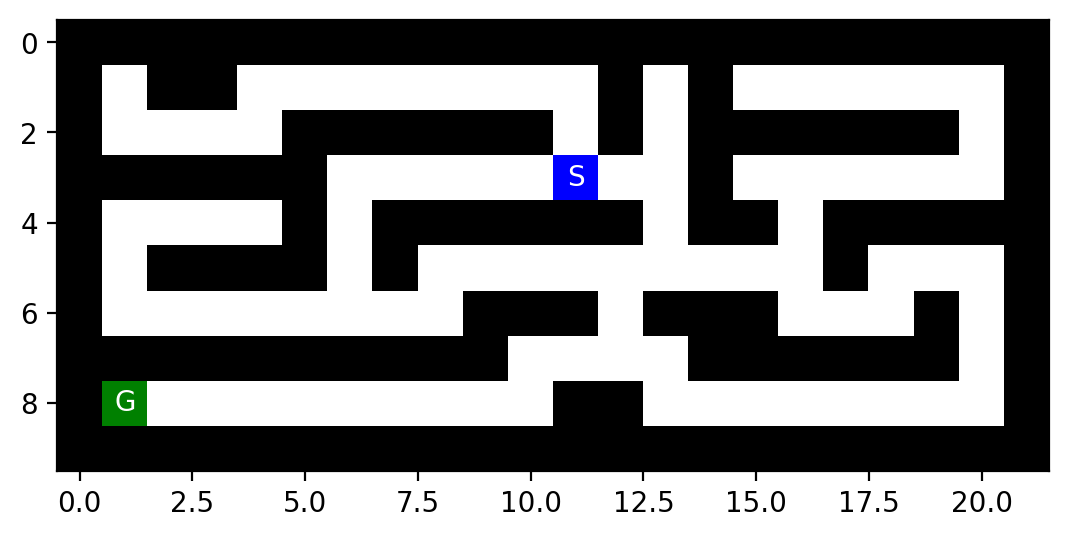

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [ ]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [ ]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment by Michael Hahsler
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step.

In [ ]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0

        # check if plan is completed
        if self.progress >= len(self.plan):
            raise Exception("Completed Plan. No more planned actions")

        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [ ]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['N', 'N', 'E', 'E', 'N', 'W', 'E', 'E', 'S', 'S']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [ ]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: N
Following plan... step 1: S
Following plan... step 2: N
Following plan... step 3: N
Following plan... step 4: E
Following plan... step 5: S
Following plan... step 6: W
Following plan... step 7: E
Following plan... step 8: S
Following plan... step 9: N
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python.
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [ ]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"

    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]

        while not node.parent is None:
            node = node.parent
            path.append(node)

        path.reverse()

        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithms for solving different mazes:

    - Breadth-first search (BFS)
    - Depth-first search (DFS)
    - Greedy best-first search (GBFS)
    - A* search

2. Run each of the above algorithms on the
    - [small maze](small_maze.txt),
    - [medium maze](medium_maze.txt),
    - [large maze](large_maze.txt),
    - [open maze](open_maze.txt),
    - [L maze](L_maze.txt),
    - [loops maze](loops_maze.txt),
    - [empty maze](empty_maze.txt), and
    - [empty maze (rotated)](empty_maze_2.txt).
    
3. For each problem instance and each search algorithm, report the following in a table:

    - The solution and its path cost
    - Total number of nodes expanded
    - Maximum tree depth
    - Maximum size of the frontier

4. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General [10 Points]

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally.
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [10 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate.

*Note:* You can swich the next block from code to Markdown and use formating.

**Initial State:**
The initial state represents the very first situation from which the problem-solving process begins. It holds all the relevant information about the system or environment at the start. For instance, if we aim to determine a route between city A and city B, the initial state would be the agent’s current location in city A.

**Actions:**
Actions define all the possible steps or movements an agent can perform from a given state. For example, if the agent is navigating a maze, the available actions could include moving upward, downward, leftward, or rightward.

**Transition Model:**
The transition model explains how an action taken in one state leads to another. It defines the rules or mapping that describe the resulting state after an agent performs a specific action. Essentially, it shows how the environment changes based on the agent’s behavior.

**Goal State:**
The goal state specifies the desired condition or outcome that the agent strives to reach. In other words, it marks the successful completion of the problem. For instance, when finding a route from city A to city B, the goal state would be the agent arriving in city B.

**Path Cost:**
The path cost measures the total expense or effort required to move from the initial state to the goal state. It depends on the problem’s nature and can represent distance, time, energy, or any other resource consumed. For example, when traveling between two cities, the path cost might correspond to the total distance or travel time between them.


Give some estimates for the problem size:

* $n$: state space size
* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determin these values for a given maze.

**State Space Size (n):**
This represents the total count of all distinct states the agent can occupy during the search process. For example, in a maze with 10 rows and 10 columns, the total number of possible positions would be ( n = 10 \times 10 = 100 ) states.

**Depth of the Optimal Solution (d):**
This indicates the minimum number of steps required to move from the initial state to the goal state through the shortest possible path. For instance, the Breadth-First Search (BFS) algorithm is ideal for finding this depth, as it always guarantees the shortest path in an unweighted maze.

**Maximum Depth of the Tree (m):**
This refers to the longest possible path or the maximum number of actions an agent can take before the search ends or all states are explored. In a grid-like maze, this can be approximately ( m = (\text{rows}) \times (\text{columns}) ).

**Maximum Branching Factor (b):**
This is the highest number of actions available from any given state. In a standard maze, an agent can usually move in four directions — up, down, left, and right — hence the branching factor ( b = 4 ).


## Task 2: Uninformed search: Breadth-first and depth-first [40 Points]

Implement these search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important notes** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.
* DSF behavior can be implemented using the BFS tree search algorithm and simply changing the order in which the frontier is expanded (this is equivalent to best-first search with path length as the criterion to expand the next node). However, this would be a big mistake since it combines the bad space complexity of BFS with the bad time complexity of DFS! **To take advantage of the significantly smaller memory footprint of DFS, you need to implement DFS in a different way without a `reached` data structure (often also called `visited` or `explored`) and by releasing the memory for nodes that are not needed anymore.**
* Since the proper implementation of DFS does not use a `reached` data structure, redundant path checking abilities are limited to cycle checking.
You need to implement **cycle checking since DSF is incomplete (produces an infinite loop) if cycles cannot be prevented.** You will see in your experiments that cycle checking in open spaces is challenging.


[small_maze.txt] BFS — Detailed Steps
  Start at (np.int64(3), np.int64(11))
  Step 1:  EAST -> (np.int64(3), np.int64(12))
  Step 2:  EAST -> (np.int64(3), np.int64(13))
  Step 3: SOUTH -> (np.int64(4), np.int64(13))
  Step 4: SOUTH -> (np.int64(5), np.int64(13))
  Step 5:  WEST -> (np.int64(5), np.int64(12))
  Step 6: SOUTH -> (np.int64(6), np.int64(12))
  Step 7: SOUTH -> (np.int64(7), np.int64(12))
  Step 8:  WEST -> (np.int64(7), np.int64(11))
  Step 9:  WEST -> (np.int64(7), np.int64(10))
  Step 10: SOUTH -> (np.int64(8), np.int64(10))
  Step 11:  WEST -> (np.int64(8), np.int64(9))
  Step 12:  WEST -> (np.int64(8), np.int64(8))
  Step 13:  WEST -> (np.int64(8), np.int64(7))
  Step 14:  WEST -> (np.int64(8), np.int64(6))
  Step 15:  WEST -> (np.int64(8), np.int64(5))
  Step 16:  WEST -> (np.int64(8), np.int64(4))
  Step 17:  WEST -> (np.int64(8), np.int64(3))
  Step 18:  WEST -> (np.int64(8), np.int64(2))
  Step 19:  WEST -> (np.int64(8), np.int64(1))
  Goal at (np.int64(8), np.i

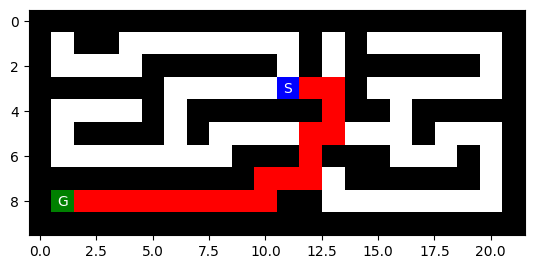


[small_maze.txt] DFS — Detailed Steps
  Start at (np.int64(3), np.int64(11))
  Step 1:  EAST -> (np.int64(3), np.int64(12))
  Step 2:  EAST -> (np.int64(3), np.int64(13))
  Step 3: SOUTH -> (np.int64(4), np.int64(13))
  Step 4: SOUTH -> (np.int64(5), np.int64(13))
  Step 5:  EAST -> (np.int64(5), np.int64(14))
  Step 6:  EAST -> (np.int64(5), np.int64(15))
  Step 7:  EAST -> (np.int64(5), np.int64(16))
  Step 8: SOUTH -> (np.int64(6), np.int64(16))
  Step 9:  EAST -> (np.int64(6), np.int64(17))
  Step 10:  EAST -> (np.int64(6), np.int64(18))
  Step 11: NORTH -> (np.int64(5), np.int64(18))
  Step 12:  EAST -> (np.int64(5), np.int64(19))
  Step 13:  EAST -> (np.int64(5), np.int64(20))
  Step 14: SOUTH -> (np.int64(6), np.int64(20))
  Step 15: SOUTH -> (np.int64(7), np.int64(20))
  Step 16: SOUTH -> (np.int64(8), np.int64(20))
  Step 17:  WEST -> (np.int64(8), np.int64(19))
  Step 18:  WEST -> (np.int64(8), np.int64(18))
  Step 19:  WEST -> (np.int64(8), np.int64(17))
  Step 20:  WEST ->

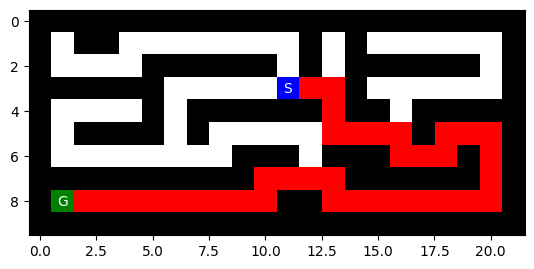


[medium_maze.txt] BFS — Detailed Steps
  Start at (np.int64(1), np.int64(34))
  Step 1:  WEST -> (np.int64(1), np.int64(33))
  Step 2:  WEST -> (np.int64(1), np.int64(32))
  Step 3:  WEST -> (np.int64(1), np.int64(31))
  Step 4:  WEST -> (np.int64(1), np.int64(30))
  Step 5:  WEST -> (np.int64(1), np.int64(29))
  Step 6:  WEST -> (np.int64(1), np.int64(28))
  Step 7:  WEST -> (np.int64(1), np.int64(27))
  Step 8:  WEST -> (np.int64(1), np.int64(26))
  Step 9:  WEST -> (np.int64(1), np.int64(25))
  Step 10: SOUTH -> (np.int64(2), np.int64(25))
  Step 11: SOUTH -> (np.int64(3), np.int64(25))
  Step 12:  EAST -> (np.int64(3), np.int64(26))
  Step 13:  EAST -> (np.int64(3), np.int64(27))
  Step 14: SOUTH -> (np.int64(4), np.int64(27))
  Step 15: SOUTH -> (np.int64(5), np.int64(27))
  Step 16: SOUTH -> (np.int64(6), np.int64(27))
  Step 17:  WEST -> (np.int64(6), np.int64(26))
  Step 18:  WEST -> (np.int64(6), np.int64(25))
  Step 19:  WEST -> (np.int64(6), np.int64(24))
  Step 20: NORTH -

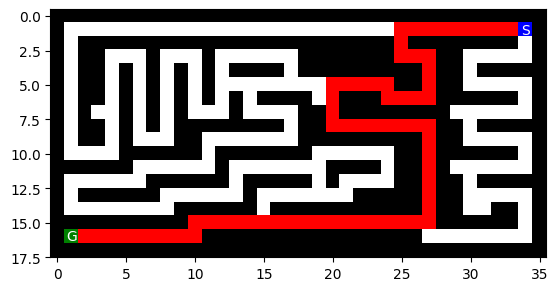


[medium_maze.txt] DFS — Detailed Steps
  Start at (np.int64(1), np.int64(34))
  Step 1: SOUTH -> (np.int64(2), np.int64(34))
  Step 2: SOUTH -> (np.int64(3), np.int64(34))
  Step 3:  WEST -> (np.int64(3), np.int64(33))
  Step 4:  WEST -> (np.int64(3), np.int64(32))
  Step 5:  WEST -> (np.int64(3), np.int64(31))
  Step 6:  WEST -> (np.int64(3), np.int64(30))
  Step 7: SOUTH -> (np.int64(4), np.int64(30))
  Step 8: SOUTH -> (np.int64(5), np.int64(30))
  Step 9:  EAST -> (np.int64(5), np.int64(31))
  Step 10:  EAST -> (np.int64(5), np.int64(32))
  Step 11:  EAST -> (np.int64(5), np.int64(33))
  Step 12:  EAST -> (np.int64(5), np.int64(34))
  Step 13: SOUTH -> (np.int64(6), np.int64(34))
  Step 14: SOUTH -> (np.int64(7), np.int64(34))
  Step 15:  WEST -> (np.int64(7), np.int64(33))
  Step 16:  WEST -> (np.int64(7), np.int64(32))
  Step 17:  WEST -> (np.int64(7), np.int64(31))
  Step 18:  WEST -> (np.int64(7), np.int64(30))
  Step 19: SOUTH -> (np.int64(8), np.int64(30))
  Step 20: SOUTH -

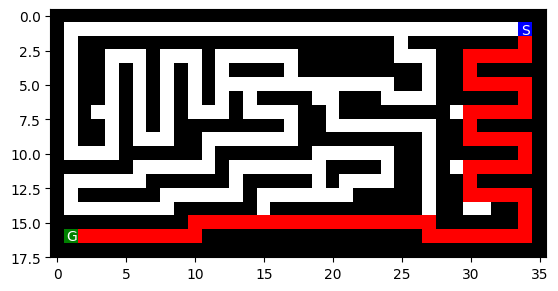


[large_maze.txt] BFS — Detailed Steps
  Start at (np.int64(35), np.int64(35))
  Step 1: NORTH -> (np.int64(34), np.int64(35))
  Step 2: NORTH -> (np.int64(33), np.int64(35))
  Step 3:  WEST -> (np.int64(33), np.int64(34))
  Step 4:  WEST -> (np.int64(33), np.int64(33))
  Step 5:  WEST -> (np.int64(33), np.int64(32))
  Step 6:  WEST -> (np.int64(33), np.int64(31))
  Step 7: NORTH -> (np.int64(32), np.int64(31))
  Step 8: NORTH -> (np.int64(31), np.int64(31))
  Step 9:  WEST -> (np.int64(31), np.int64(30))
  Step 10:  WEST -> (np.int64(31), np.int64(29))
  Step 11: SOUTH -> (np.int64(32), np.int64(29))
  Step 12: SOUTH -> (np.int64(33), np.int64(29))
  Step 13:  WEST -> (np.int64(33), np.int64(28))
  Step 14:  WEST -> (np.int64(33), np.int64(27))
  Step 15:  WEST -> (np.int64(33), np.int64(26))
  Step 16:  WEST -> (np.int64(33), np.int64(25))
  Step 17:  WEST -> (np.int64(33), np.int64(24))
  Step 18:  WEST -> (np.int64(33), np.int64(23))
  Step 19:  WEST -> (np.int64(33), np.int64(22))

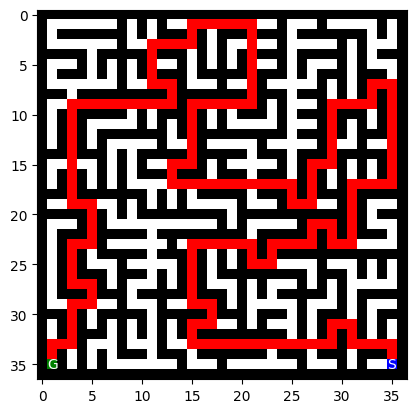


[large_maze.txt] DFS — Detailed Steps
  Start at (np.int64(35), np.int64(35))
  Step 1: NORTH -> (np.int64(34), np.int64(35))
  Step 2: NORTH -> (np.int64(33), np.int64(35))
  Step 3:  WEST -> (np.int64(33), np.int64(34))
  Step 4:  WEST -> (np.int64(33), np.int64(33))
  Step 5:  WEST -> (np.int64(33), np.int64(32))
  Step 6:  WEST -> (np.int64(33), np.int64(31))
  Step 7: NORTH -> (np.int64(32), np.int64(31))
  Step 8: NORTH -> (np.int64(31), np.int64(31))
  Step 9:  WEST -> (np.int64(31), np.int64(30))
  Step 10:  WEST -> (np.int64(31), np.int64(29))
  Step 11: SOUTH -> (np.int64(32), np.int64(29))
  Step 12: SOUTH -> (np.int64(33), np.int64(29))
  Step 13:  WEST -> (np.int64(33), np.int64(28))
  Step 14:  WEST -> (np.int64(33), np.int64(27))
  Step 15:  WEST -> (np.int64(33), np.int64(26))
  Step 16:  WEST -> (np.int64(33), np.int64(25))
  Step 17:  WEST -> (np.int64(33), np.int64(24))
  Step 18:  WEST -> (np.int64(33), np.int64(23))
  Step 19:  WEST -> (np.int64(33), np.int64(22))

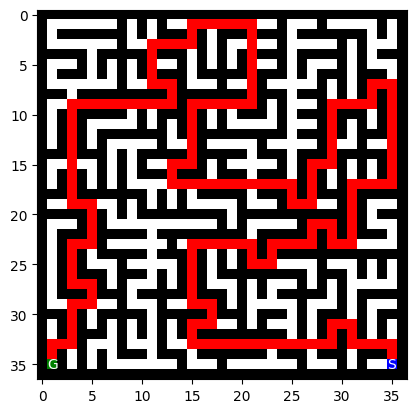


[loops_maze.txt] BFS — Detailed Steps
  Start at (np.int64(10), np.int64(1))
  Step 1:  EAST -> (np.int64(10), np.int64(2))
  Step 2:  EAST -> (np.int64(10), np.int64(3))
  Step 3:  EAST -> (np.int64(10), np.int64(4))
  Step 4:  EAST -> (np.int64(10), np.int64(5))
  Step 5:  EAST -> (np.int64(10), np.int64(6))
  Step 6:  EAST -> (np.int64(10), np.int64(7))
  Step 7:  EAST -> (np.int64(10), np.int64(8))
  Step 8: NORTH -> (np.int64(9), np.int64(8))
  Step 9: NORTH -> (np.int64(8), np.int64(8))
  Step 10: NORTH -> (np.int64(7), np.int64(8))
  Step 11: NORTH -> (np.int64(6), np.int64(8))
  Step 12: NORTH -> (np.int64(5), np.int64(8))
  Step 13: NORTH -> (np.int64(4), np.int64(8))
  Step 14: NORTH -> (np.int64(3), np.int64(8))
  Step 15: NORTH -> (np.int64(2), np.int64(8))
  Step 16: NORTH -> (np.int64(1), np.int64(8))
  Step 17:  WEST -> (np.int64(1), np.int64(7))
  Step 18:  WEST -> (np.int64(1), np.int64(6))
  Step 19:  WEST -> (np.int64(1), np.int64(5))
  Step 20:  WEST -> (np.int64(1

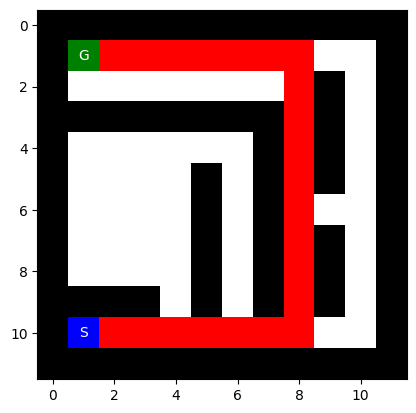


[loops_maze.txt] DFS — Detailed Steps
  Start at (np.int64(10), np.int64(1))
  Step 1:  EAST -> (np.int64(10), np.int64(2))
  Step 2:  EAST -> (np.int64(10), np.int64(3))
  Step 3:  EAST -> (np.int64(10), np.int64(4))
  Step 4:  EAST -> (np.int64(10), np.int64(5))
  Step 5:  EAST -> (np.int64(10), np.int64(6))
  Step 6:  EAST -> (np.int64(10), np.int64(7))
  Step 7:  EAST -> (np.int64(10), np.int64(8))
  Step 8:  EAST -> (np.int64(10), np.int64(9))
  Step 9:  EAST -> (np.int64(10), np.int64(10))
  Step 10: NORTH -> (np.int64(9), np.int64(10))
  Step 11: NORTH -> (np.int64(8), np.int64(10))
  Step 12: NORTH -> (np.int64(7), np.int64(10))
  Step 13: NORTH -> (np.int64(6), np.int64(10))
  Step 14:  WEST -> (np.int64(6), np.int64(9))
  Step 15:  WEST -> (np.int64(6), np.int64(8))
  Step 16: NORTH -> (np.int64(5), np.int64(8))
  Step 17: NORTH -> (np.int64(4), np.int64(8))
  Step 18: NORTH -> (np.int64(3), np.int64(8))
  Step 19: NORTH -> (np.int64(2), np.int64(8))
  Step 20:  WEST -> (np.

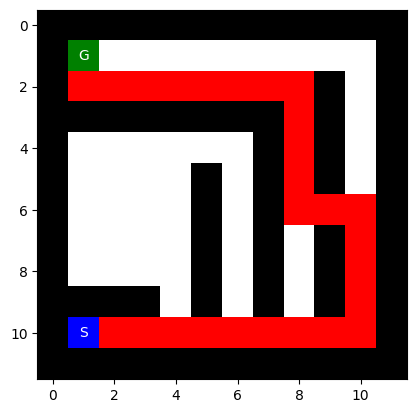


[L_maze.txt] BFS — Detailed Steps
  Start at (np.int64(9), np.int64(5))
  Step 1:  EAST -> (np.int64(9), np.int64(6))
  Step 2:  EAST -> (np.int64(9), np.int64(7))
  Step 3:  EAST -> (np.int64(9), np.int64(8))
  Step 4:  EAST -> (np.int64(9), np.int64(9))
  Step 5: SOUTH -> (np.int64(10), np.int64(9))
  Step 6:  EAST -> (np.int64(10), np.int64(10))
  Step 7:  EAST -> (np.int64(10), np.int64(11))
  Step 8: NORTH -> (np.int64(9), np.int64(11))
  Step 9: NORTH -> (np.int64(8), np.int64(11))
  Step 10: NORTH -> (np.int64(7), np.int64(11))
  Step 11: NORTH -> (np.int64(6), np.int64(11))
  Step 12: NORTH -> (np.int64(5), np.int64(11))
  Step 13: NORTH -> (np.int64(4), np.int64(11))
  Step 14: NORTH -> (np.int64(3), np.int64(11))
  Step 15: NORTH -> (np.int64(2), np.int64(11))
  Step 16:  EAST -> (np.int64(2), np.int64(12))
  Goal at (np.int64(2), np.int64(12))
  Total path cost: 16


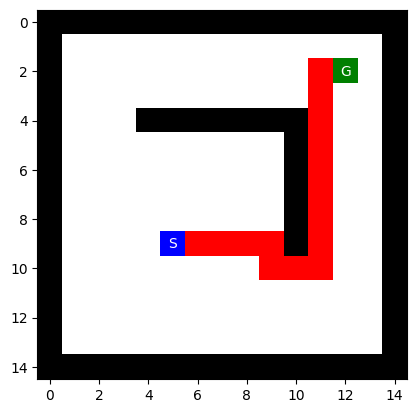


[L_maze.txt] DFS — Detailed Steps
  Start at (np.int64(9), np.int64(5))
  Step 1:  EAST -> (np.int64(9), np.int64(6))
  Step 2:  EAST -> (np.int64(9), np.int64(7))
  Step 3:  EAST -> (np.int64(9), np.int64(8))
  Step 4:  EAST -> (np.int64(9), np.int64(9))
  Step 5: SOUTH -> (np.int64(10), np.int64(9))
  Step 6:  EAST -> (np.int64(10), np.int64(10))
  Step 7:  EAST -> (np.int64(10), np.int64(11))
  Step 8:  EAST -> (np.int64(10), np.int64(12))
  Step 9:  EAST -> (np.int64(10), np.int64(13))
  Step 10: SOUTH -> (np.int64(11), np.int64(13))
  Step 11: SOUTH -> (np.int64(12), np.int64(13))
  Step 12: SOUTH -> (np.int64(13), np.int64(13))
  Step 13:  WEST -> (np.int64(13), np.int64(12))
  Step 14:  WEST -> (np.int64(13), np.int64(11))
  Step 15:  WEST -> (np.int64(13), np.int64(10))
  Step 16:  WEST -> (np.int64(13), np.int64(9))
  Step 17:  WEST -> (np.int64(13), np.int64(8))
  Step 18:  WEST -> (np.int64(13), np.int64(7))
  Step 19:  WEST -> (np.int64(13), np.int64(6))
  Step 20:  WEST -

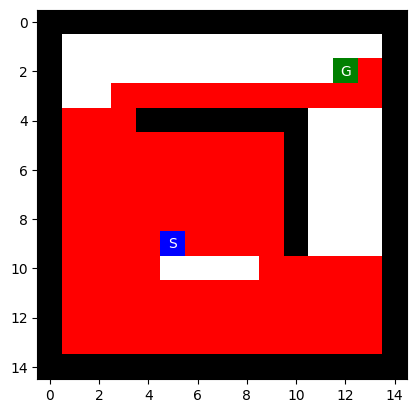


[empty_maze.txt] BFS — Detailed Steps
  Start at (np.int64(9), np.int64(2))
  Step 1: NORTH -> (np.int64(8), np.int64(2))
  Step 2: NORTH -> (np.int64(7), np.int64(2))
  Step 3: NORTH -> (np.int64(6), np.int64(2))
  Step 4: NORTH -> (np.int64(5), np.int64(2))
  Step 5: NORTH -> (np.int64(4), np.int64(2))
  Step 6: NORTH -> (np.int64(3), np.int64(2))
  Step 7: NORTH -> (np.int64(2), np.int64(2))
  Step 8:  EAST -> (np.int64(2), np.int64(3))
  Step 9:  EAST -> (np.int64(2), np.int64(4))
  Step 10:  EAST -> (np.int64(2), np.int64(5))
  Step 11:  EAST -> (np.int64(2), np.int64(6))
  Step 12:  EAST -> (np.int64(2), np.int64(7))
  Step 13:  EAST -> (np.int64(2), np.int64(8))
  Step 14:  EAST -> (np.int64(2), np.int64(9))
  Goal at (np.int64(2), np.int64(9))
  Total path cost: 14


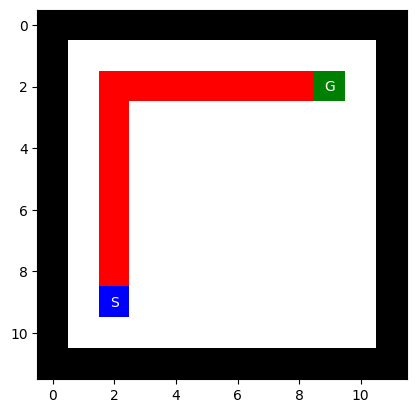


[empty_maze.txt] DFS — Detailed Steps
  Start at (np.int64(9), np.int64(2))
  Step 1:  EAST -> (np.int64(9), np.int64(3))
  Step 2:  EAST -> (np.int64(9), np.int64(4))
  Step 3:  EAST -> (np.int64(9), np.int64(5))
  Step 4:  EAST -> (np.int64(9), np.int64(6))
  Step 5:  EAST -> (np.int64(9), np.int64(7))
  Step 6:  EAST -> (np.int64(9), np.int64(8))
  Step 7:  EAST -> (np.int64(9), np.int64(9))
  Step 8:  EAST -> (np.int64(9), np.int64(10))
  Step 9: SOUTH -> (np.int64(10), np.int64(10))
  Step 10:  WEST -> (np.int64(10), np.int64(9))
  Step 11:  WEST -> (np.int64(10), np.int64(8))
  Step 12:  WEST -> (np.int64(10), np.int64(7))
  Step 13:  WEST -> (np.int64(10), np.int64(6))
  Step 14:  WEST -> (np.int64(10), np.int64(5))
  Step 15:  WEST -> (np.int64(10), np.int64(4))
  Step 16:  WEST -> (np.int64(10), np.int64(3))
  Step 17:  WEST -> (np.int64(10), np.int64(2))
  Step 18:  WEST -> (np.int64(10), np.int64(1))
  Step 19: NORTH -> (np.int64(9), np.int64(1))
  Step 20: NORTH -> (np.int

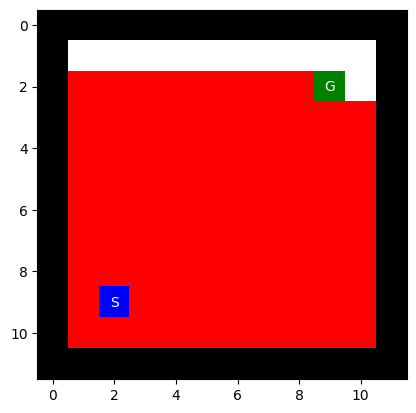


[empty_maze_2.txt] BFS — Detailed Steps
  Start at (np.int64(2), np.int64(9))
  Step 1: SOUTH -> (np.int64(3), np.int64(9))
  Step 2: SOUTH -> (np.int64(4), np.int64(9))
  Step 3: SOUTH -> (np.int64(5), np.int64(9))
  Step 4: SOUTH -> (np.int64(6), np.int64(9))
  Step 5: SOUTH -> (np.int64(7), np.int64(9))
  Step 6: SOUTH -> (np.int64(8), np.int64(9))
  Step 7: SOUTH -> (np.int64(9), np.int64(9))
  Step 8:  WEST -> (np.int64(9), np.int64(8))
  Step 9:  WEST -> (np.int64(9), np.int64(7))
  Step 10:  WEST -> (np.int64(9), np.int64(6))
  Step 11:  WEST -> (np.int64(9), np.int64(5))
  Step 12:  WEST -> (np.int64(9), np.int64(4))
  Step 13:  WEST -> (np.int64(9), np.int64(3))
  Step 14:  WEST -> (np.int64(9), np.int64(2))
  Goal at (np.int64(9), np.int64(2))
  Total path cost: 14


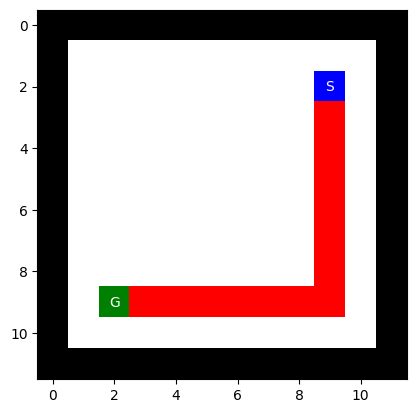


[empty_maze_2.txt] DFS — Detailed Steps
  Start at (np.int64(2), np.int64(9))
  Step 1:  EAST -> (np.int64(2), np.int64(10))
  Step 2: SOUTH -> (np.int64(3), np.int64(10))
  Step 3: SOUTH -> (np.int64(4), np.int64(10))
  Step 4: SOUTH -> (np.int64(5), np.int64(10))
  Step 5: SOUTH -> (np.int64(6), np.int64(10))
  Step 6: SOUTH -> (np.int64(7), np.int64(10))
  Step 7: SOUTH -> (np.int64(8), np.int64(10))
  Step 8: SOUTH -> (np.int64(9), np.int64(10))
  Step 9: SOUTH -> (np.int64(10), np.int64(10))
  Step 10:  WEST -> (np.int64(10), np.int64(9))
  Step 11:  WEST -> (np.int64(10), np.int64(8))
  Step 12:  WEST -> (np.int64(10), np.int64(7))
  Step 13:  WEST -> (np.int64(10), np.int64(6))
  Step 14:  WEST -> (np.int64(10), np.int64(5))
  Step 15:  WEST -> (np.int64(10), np.int64(4))
  Step 16:  WEST -> (np.int64(10), np.int64(3))
  Step 17:  WEST -> (np.int64(10), np.int64(2))
  Step 18:  WEST -> (np.int64(10), np.int64(1))
  Step 19: NORTH -> (np.int64(9), np.int64(1))
  Step 20:  EAST -

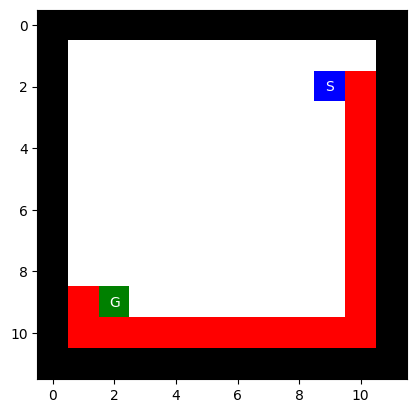


[open_maze.txt] BFS — Detailed Steps
  Start at (np.int64(1), np.int64(35))
  Step 1: SOUTH -> (np.int64(2), np.int64(35))
  Step 2: SOUTH -> (np.int64(3), np.int64(35))
  Step 3: SOUTH -> (np.int64(4), np.int64(35))
  Step 4: SOUTH -> (np.int64(5), np.int64(35))
  Step 5: SOUTH -> (np.int64(6), np.int64(35))
  Step 6:  WEST -> (np.int64(6), np.int64(34))
  Step 7:  WEST -> (np.int64(6), np.int64(33))
  Step 8:  WEST -> (np.int64(6), np.int64(32))
  Step 9:  WEST -> (np.int64(6), np.int64(31))
  Step 10:  WEST -> (np.int64(6), np.int64(30))
  Step 11:  WEST -> (np.int64(6), np.int64(29))
  Step 12:  WEST -> (np.int64(6), np.int64(28))
  Step 13:  WEST -> (np.int64(6), np.int64(27))
  Step 14:  WEST -> (np.int64(6), np.int64(26))
  Step 15:  WEST -> (np.int64(6), np.int64(25))
  Step 16:  WEST -> (np.int64(6), np.int64(24))
  Step 17:  WEST -> (np.int64(6), np.int64(23))
  Step 18:  WEST -> (np.int64(6), np.int64(22))
  Step 19:  WEST -> (np.int64(6), np.int64(21))
  Step 20:  WEST -> 

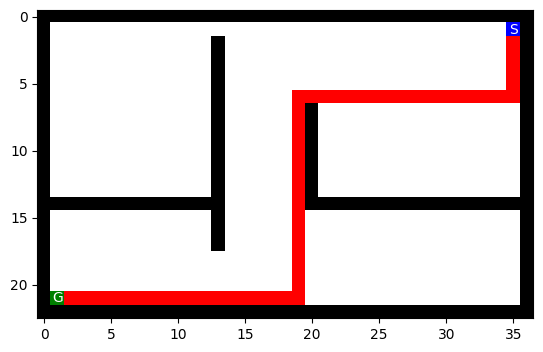


[open_maze.txt] DFS — Detailed Steps
  Start at (np.int64(1), np.int64(35))
  Step 1: SOUTH -> (np.int64(2), np.int64(35))
  Step 2: SOUTH -> (np.int64(3), np.int64(35))
  Step 3: SOUTH -> (np.int64(4), np.int64(35))
  Step 4: SOUTH -> (np.int64(5), np.int64(35))
  Step 5: SOUTH -> (np.int64(6), np.int64(35))
  Step 6: SOUTH -> (np.int64(7), np.int64(35))
  Step 7: SOUTH -> (np.int64(8), np.int64(35))
  Step 8: SOUTH -> (np.int64(9), np.int64(35))
  Step 9: SOUTH -> (np.int64(10), np.int64(35))
  Step 10: SOUTH -> (np.int64(11), np.int64(35))
  Step 11: SOUTH -> (np.int64(12), np.int64(35))
  Step 12: SOUTH -> (np.int64(13), np.int64(35))
  Step 13:  WEST -> (np.int64(13), np.int64(34))
  Step 14:  WEST -> (np.int64(13), np.int64(33))
  Step 15:  WEST -> (np.int64(13), np.int64(32))
  Step 16:  WEST -> (np.int64(13), np.int64(31))
  Step 17:  WEST -> (np.int64(13), np.int64(30))
  Step 18:  WEST -> (np.int64(13), np.int64(29))
  Step 19:  WEST -> (np.int64(13), np.int64(28))
  Step 20

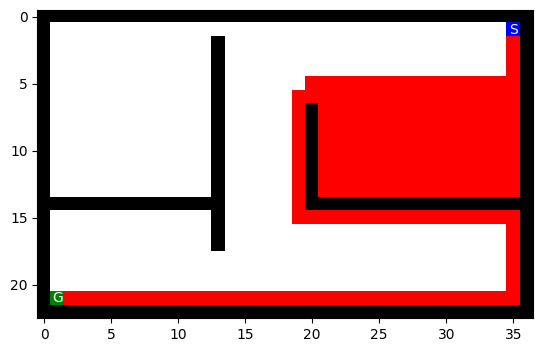


=== Search Results ===
            Maze Algorithm  Path Cost  Nodes Expanded  Max Frontier Size  Max Depth Reached  Max Branching Observed
  small_maze.txt       BFS         19              93                  9                 19                       3
  small_maze.txt       DFS         37              37                 38                 37                       3
 medium_maze.txt       BFS         68             270                  9                 68                       2
 medium_maze.txt       DFS         74              74                 75                 74                       3
  large_maze.txt       BFS        210             622                  8                210                       3
  large_maze.txt       DFS        210             417                223                222                       4
  loops_maze.txt       BFS         23              72                  8                 23                       2
  loops_maze.txt       DFS         27           

In [15]:
# search_strategies.py
from collections import deque
from dataclasses import dataclass
import copy
import pandas as pd
import maze_helper as mh

DIRECTIONS = {
    "north": (-1, 0),
    "east":  (0, 1),
    "south": (1, 0),
    "west":  (0, -1),
}

@dataclass
class Node:
    pos: tuple
    parent: "Node"
    action: str
    depth: int

def successors(maze, pos, directions):
    for action, d in directions.items():
        nxt = (pos[0] + d[0], pos[1] + d[1])
        if mh.look(maze, nxt) != "X":
            yield action, nxt

def rebuild_path(goal_node):
    path_nodes = []
    n = goal_node
    while n is not None:
        path_nodes.append(n)
        n = n.parent
    path_nodes.reverse()  # start -> goal
    return path_nodes  # list[Node]

def overlay_path_on_maze(maze, path_pos, start, goal, path_char="P"):
    grid = copy.deepcopy(maze)
    for p in path_pos:
        if p != start and p != goal:
            grid[p[0]][p[1]] = path_char
    grid[start[0]][start[1]] = "S"
    grid[goal[0]][goal[1]] = "G"
    return grid

def bfs_tree_search(maze, start, goal, directions=DIRECTIONS):
    frontier = deque([Node(start, None, None, 0)])
    reached = {start}
    nodes_expanded = 0
    max_frontier = 1
    max_depth = 0
    max_branching = 0

    while frontier:
        max_frontier = max(max_frontier, len(frontier))
        node = frontier.popleft()
        nodes_expanded += 1
        max_depth = max(max_depth, node.depth)

        if node.pos == goal:
            return node, {
                "nodes_expanded": nodes_expanded,
                "max_frontier": max_frontier,
                "max_depth": max_depth,
                "max_branching": max_branching,
            }

        branch_count = 0
        for action, nxt in successors(maze, node.pos, directions):
            if nxt not in reached:
                reached.add(nxt)
                frontier.append(Node(nxt, node, action, node.depth + 1))
                branch_count += 1
        max_branching = max(max_branching, branch_count)

    return None, {
        "nodes_expanded": nodes_expanded,
        "max_frontier": max_frontier,
        "max_depth": max_depth,
        "max_branching": max_branching,
    }

def dfs_tree_search(maze, start, goal, directions=DIRECTIONS):
    start_node = Node(start, None, None, 0)
    stack = [(start_node, iter(successors(maze, start, directions)))]
    ancestors = {start}
    nodes_expanded = 0
    max_frontier = 1
    max_depth = 0
    max_branching = 0
    expanded_once = set()

    def succ_list(p):
        return [s for s in successors(maze, p, directions)]

    while stack:
        max_frontier = max(max_frontier, len(stack))
        node, it = stack[-1]
        max_depth = max(max_depth, node.depth)

        if node.pos == goal:
            return node, {
                "nodes_expanded": nodes_expanded,
                "max_frontier": max_frontier,
                "max_depth": max_depth,
                "max_branching": max_branching,
            }

        if node.pos not in expanded_once:
            expanded_once.add(node.pos)
            nodes_expanded += 1
            kids = succ_list(node.pos)
            max_branching = max(max_branching, len(kids))
            stack[-1] = (node, iter(kids))
            it = stack[-1][1]

        try:
            action, nxt = next(it)
        except StopIteration:
            stack.pop()
            ancestors.discard(node.pos)
            continue

        if nxt in ancestors:
            continue

        child = Node(nxt, node, action, node.depth + 1)
        stack.append((child, iter(())))
        ancestors.add(nxt)

    return None, {
        "nodes_expanded": nodes_expanded,
        "max_frontier": max_frontier,
        "max_depth": max_depth,
        "max_branching": max_branching,
    }

def print_steps(path_nodes, start, goal, maze_name, algo):
    print(f"\n[{maze_name}] {algo} — Detailed Steps")
    if not path_nodes:
        print("  Goal not found.")
        return
    # path_nodes: list[Node] from start -> goal
    print(f"  Start at {start}")
    # Skip index 0 (start) because it has no action
    for i in range(1, len(path_nodes)):
        step_node = path_nodes[i]
        print(f"  Step {i}: {step_node.action.upper():>5} -> {step_node.pos}")
    print(f"  Goal at {goal}")
    print(f"  Total path cost: {len(path_nodes) - 1}")

def run_on_maze(maze_text, algo="BFS", maze_name="(in-memory)"):
    maze = mh.parse_maze(maze_text)
    start = mh.find_pos(maze, what="S")
    goal = mh.find_pos(maze, what="G")

    if algo.upper() == "BFS":
        goal_node, stats = bfs_tree_search(maze, start, goal, directions=DIRECTIONS)
        algo_name = "BFS"
    elif algo.upper() == "DFS":
        dfs_dirs = {
            "east":  (0, 1),
            "south": (1, 0),
            "west":  (0, -1),
            "north": (-1, 0),
        }
        goal_node, stats = dfs_tree_search(maze, start, goal, directions=dfs_dirs)
        algo_name = "DFS"
    else:
        raise ValueError(f"Unknown algo: {algo}")

    if goal_node is None:
        print(f"[{maze_name}] {algo_name}: Goal not found.")
        return None, stats

    path_nodes = rebuild_path(goal_node)
    print_steps(path_nodes, start, goal, maze_name, algo_name)

    path_pos = [n.pos for n in path_nodes]
    drawn = overlay_path_on_maze(maze, path_pos, start, goal, path_char="P")
    mh.show_maze(drawn)
    return path_nodes, stats

def run_on_files(file_list, algos=("BFS", "DFS")):
    rows = []
    for fname in file_list:
        try:
            with open(fname, "r") as f:
                maze_text = f.read()
        except FileNotFoundError:
            print(f"Skipping missing file: {fname}")
            continue

        for algo in algos:
            path_nodes, stats = run_on_maze(maze_text, algo=algo, maze_name=fname)
            rows.append({
                "Maze": fname,
                "Algorithm": algo,
                "Path Cost": (len(path_nodes) - 1) if path_nodes else None,
                "Nodes Expanded": stats["nodes_expanded"],
                "Max Frontier Size": stats["max_frontier"],
                "Max Depth Reached": stats["max_depth"],
                "Max Branching Observed": stats["max_branching"],
            })

    df = pd.DataFrame(rows, columns=[
        "Maze", "Algorithm", "Path Cost",
        "Nodes Expanded", "Max Frontier Size",
        "Max Depth Reached", "Max Branching Observed"
    ])
    return df

if __name__ == "__main__":
    maze_files = [
        "small_maze.txt",
        "medium_maze.txt",
        "large_maze.txt",
        "loops_maze.txt",
        "L_maze.txt",
        "empty_maze.txt",
        "empty_maze_2.txt",
        "open_maze.txt",
    ]
    results = run_on_files(maze_files, algos=("BFS", "DFS"))
    print("\n=== Search Results ===")
    print(results.to_string(index=False))


How does BFS and DFS (without a reached data structure) deal with loops (cycles)?

**Without a “reached/visited” set, cycles break both searches.**
In graphs or mazes that contain loops, omitting a record of already-seen states allows the search to revisit the same positions endlessly.

* **BFS:** Because it expands the frontier level by level, the same node can be enqueued repeatedly through different paths. That redundancy causes ballooning queues, wasted expansions, and heavy memory use—slowing the search dramatically.
* **DFS:** Since it follows one path as deep as possible, it can descend into a cycle and keep looping over the same subset of nodes indefinitely, never backing out to find the goal.

**Bottom line:** a reached/visited structure is essential to prevent repeated work, avoid infinite loops, and keep both BFS and DFS efficient and terminating.


Are your implementations complete and optimal? Explain why. What is the time and space complexity of each of **your** implementations? Especially discuss the difference in space complexity between BFS and DFS.

**Breadth-First Search (BFS):**
BFS is both **complete** and **optimal**. It will always find a solution if one exists and guarantees the **shortest path** in an unweighted maze since it explores nodes level by level.

* **Time Complexity:** ( O(b^d) ) — BFS expands every possible node at each depth level until it reaches the goal.
* **Space Complexity:** ( O(b^d) ) — It must store all nodes in the current frontier (same depth), which consumes a large amount of memory.

**Depth-First Search (DFS):**
DFS is **not always complete** in the presence of cycles, as it can get trapped exploring an infinite loop. It is also **not optimal**, since it might find a longer or suboptimal path before the shortest one.

* **Time Complexity:** ( O(b^d) ) — DFS may explore deeply along one path before backtracking, leading to a similar exponential time cost.
* **Space Complexity:** ( O(bd) ) — It keeps only a single path from the root to a leaf at a time, making it much more memory-efficient compared to BFS.


## Task 3: Informed search: Implement greedy best-first search and A* search  [20 Points]

You can use the map to estimate the distance from your current position to the goal using the Manhattan distance (see https://en.wikipedia.org/wiki/Taxicab_geometry) as a heuristic function. Both algorithms are based on Best-First search which requires only a small change from the BFS algorithm you have already implemented (see textbook/slides).

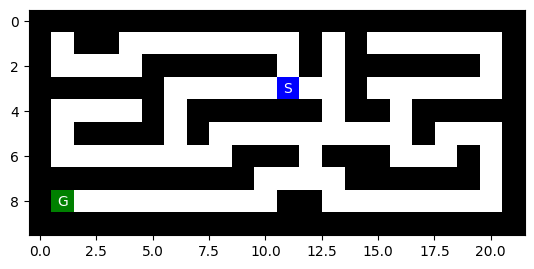


Path from start to goal:
Start: (np.int64(3), np.int64(11))
Step 1: (np.int64(3), np.int64(10))
Step 2: (np.int64(3), np.int64(9))
Step 3: (np.int64(3), np.int64(8))
Step 4: (np.int64(3), np.int64(7))
Step 5: (np.int64(3), np.int64(6))
Step 6: (np.int64(4), np.int64(6))
Step 7: (np.int64(5), np.int64(6))
Step 8: (np.int64(6), np.int64(6))
Step 9: (np.int64(6), np.int64(7))
Step 10: (np.int64(6), np.int64(8))
Step 11: (np.int64(5), np.int64(8))
Step 12: (np.int64(5), np.int64(9))
Step 13: (np.int64(5), np.int64(10))
Step 14: (np.int64(5), np.int64(11))
Step 15: (np.int64(5), np.int64(12))
Step 16: (np.int64(6), np.int64(12))
Step 17: (np.int64(7), np.int64(12))
Step 18: (np.int64(7), np.int64(11))
Step 19: (np.int64(7), np.int64(10))
Step 20: (np.int64(8), np.int64(10))
Step 21: (np.int64(8), np.int64(9))
Step 22: (np.int64(8), np.int64(8))
Step 23: (np.int64(8), np.int64(7))
Step 24: (np.int64(8), np.int64(6))
Step 25: (np.int64(8), np.int64(5))
Step 26: (np.int64(8), np.int64(4))
Ste

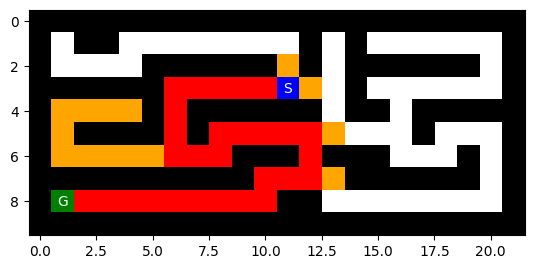

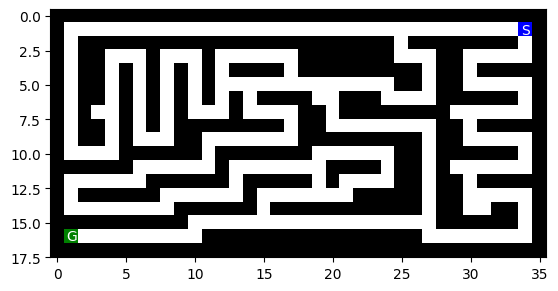


Path from start to goal:
Start: (np.int64(1), np.int64(34))
Step 1: (np.int64(2), np.int64(34))
Step 2: (np.int64(3), np.int64(34))
Step 3: (np.int64(3), np.int64(33))
Step 4: (np.int64(3), np.int64(32))
Step 5: (np.int64(3), np.int64(31))
Step 6: (np.int64(3), np.int64(30))
Step 7: (np.int64(4), np.int64(30))
Step 8: (np.int64(5), np.int64(30))
Step 9: (np.int64(5), np.int64(31))
Step 10: (np.int64(5), np.int64(32))
Step 11: (np.int64(5), np.int64(33))
Step 12: (np.int64(5), np.int64(34))
Step 13: (np.int64(6), np.int64(34))
Step 14: (np.int64(7), np.int64(34))
Step 15: (np.int64(7), np.int64(33))
Step 16: (np.int64(7), np.int64(32))
Step 17: (np.int64(7), np.int64(31))
Step 18: (np.int64(7), np.int64(30))
Step 19: (np.int64(8), np.int64(30))
Step 20: (np.int64(9), np.int64(30))
Step 21: (np.int64(9), np.int64(31))
Step 22: (np.int64(9), np.int64(32))
Step 23: (np.int64(9), np.int64(33))
Step 24: (np.int64(9), np.int64(34))
Step 25: (np.int64(10), np.int64(34))
Step 26: (np.int64(11)

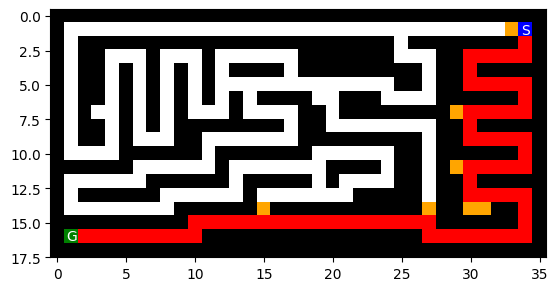

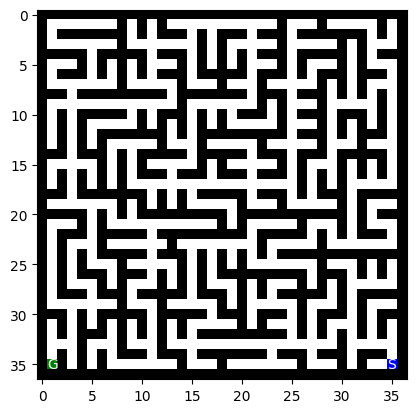


Path from start to goal:
Start: (np.int64(35), np.int64(35))
Step 1: (np.int64(34), np.int64(35))
Step 2: (np.int64(33), np.int64(35))
Step 3: (np.int64(33), np.int64(34))
Step 4: (np.int64(33), np.int64(33))
Step 5: (np.int64(33), np.int64(32))
Step 6: (np.int64(33), np.int64(31))
Step 7: (np.int64(32), np.int64(31))
Step 8: (np.int64(31), np.int64(31))
Step 9: (np.int64(31), np.int64(30))
Step 10: (np.int64(31), np.int64(29))
Step 11: (np.int64(32), np.int64(29))
Step 12: (np.int64(33), np.int64(29))
Step 13: (np.int64(33), np.int64(28))
Step 14: (np.int64(33), np.int64(27))
Step 15: (np.int64(33), np.int64(26))
Step 16: (np.int64(33), np.int64(25))
Step 17: (np.int64(33), np.int64(24))
Step 18: (np.int64(33), np.int64(23))
Step 19: (np.int64(33), np.int64(22))
Step 20: (np.int64(33), np.int64(21))
Step 21: (np.int64(33), np.int64(20))
Step 22: (np.int64(33), np.int64(19))
Step 23: (np.int64(33), np.int64(18))
Step 24: (np.int64(33), np.int64(17))
Step 25: (np.int64(33), np.int64(16

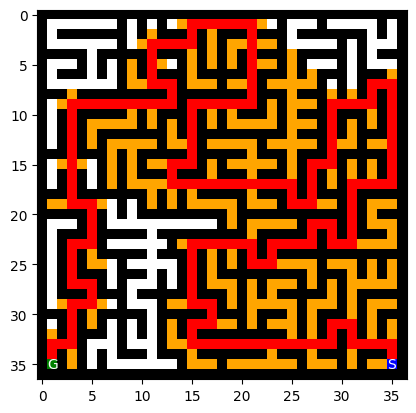

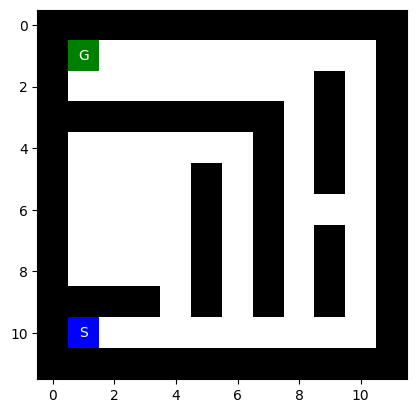


Path from start to goal:
Start: (np.int64(10), np.int64(1))
Step 1: (np.int64(10), np.int64(2))
Step 2: (np.int64(10), np.int64(3))
Step 3: (np.int64(10), np.int64(4))
Step 4: (np.int64(10), np.int64(5))
Step 5: (np.int64(10), np.int64(6))
Step 6: (np.int64(10), np.int64(7))
Step 7: (np.int64(10), np.int64(8))
Step 8: (np.int64(9), np.int64(8))
Step 9: (np.int64(8), np.int64(8))
Step 10: (np.int64(7), np.int64(8))
Step 11: (np.int64(6), np.int64(8))
Step 12: (np.int64(5), np.int64(8))
Step 13: (np.int64(4), np.int64(8))
Step 14: (np.int64(3), np.int64(8))
Step 15: (np.int64(2), np.int64(8))
Step 16: (np.int64(1), np.int64(8))
Step 17: (np.int64(1), np.int64(7))
Step 18: (np.int64(1), np.int64(6))
Step 19: (np.int64(1), np.int64(5))
Step 20: (np.int64(1), np.int64(4))
Step 21: (np.int64(1), np.int64(3))
Step 22: (np.int64(1), np.int64(2))
Goal: (np.int64(1), np.int64(1))
Total Path Cost: 23


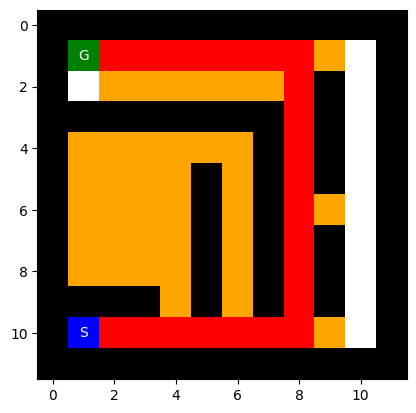

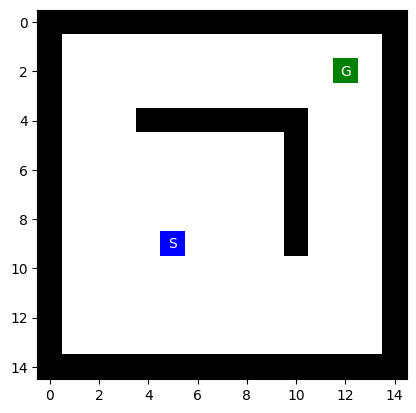


Path from start to goal:
Start: (np.int64(9), np.int64(5))
Step 1: (np.int64(8), np.int64(5))
Step 2: (np.int64(7), np.int64(5))
Step 3: (np.int64(6), np.int64(5))
Step 4: (np.int64(5), np.int64(5))
Step 5: (np.int64(5), np.int64(6))
Step 6: (np.int64(5), np.int64(7))
Step 7: (np.int64(5), np.int64(8))
Step 8: (np.int64(5), np.int64(9))
Step 9: (np.int64(6), np.int64(9))
Step 10: (np.int64(7), np.int64(9))
Step 11: (np.int64(8), np.int64(9))
Step 12: (np.int64(9), np.int64(9))
Step 13: (np.int64(10), np.int64(9))
Step 14: (np.int64(10), np.int64(10))
Step 15: (np.int64(10), np.int64(11))
Step 16: (np.int64(9), np.int64(11))
Step 17: (np.int64(8), np.int64(11))
Step 18: (np.int64(7), np.int64(11))
Step 19: (np.int64(6), np.int64(11))
Step 20: (np.int64(5), np.int64(11))
Step 21: (np.int64(4), np.int64(11))
Step 22: (np.int64(3), np.int64(11))
Step 23: (np.int64(2), np.int64(11))
Goal: (np.int64(2), np.int64(12))
Total Path Cost: 24


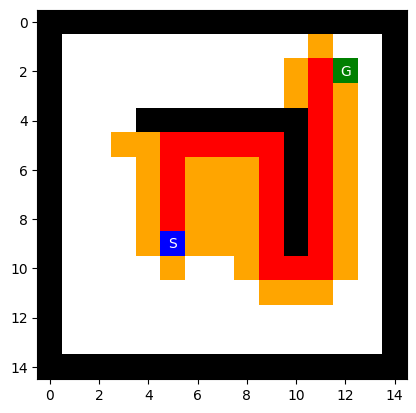

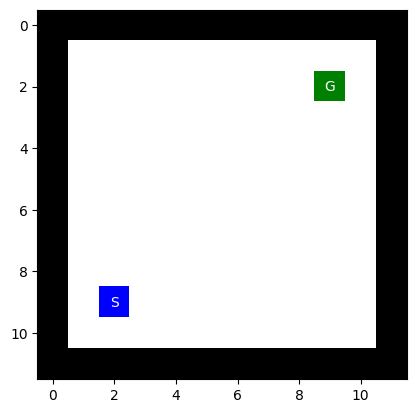


Path from start to goal:
Start: (np.int64(9), np.int64(2))
Step 1: (np.int64(8), np.int64(2))
Step 2: (np.int64(7), np.int64(2))
Step 3: (np.int64(6), np.int64(2))
Step 4: (np.int64(5), np.int64(2))
Step 5: (np.int64(4), np.int64(2))
Step 6: (np.int64(3), np.int64(2))
Step 7: (np.int64(2), np.int64(2))
Step 8: (np.int64(2), np.int64(3))
Step 9: (np.int64(2), np.int64(4))
Step 10: (np.int64(2), np.int64(5))
Step 11: (np.int64(2), np.int64(6))
Step 12: (np.int64(2), np.int64(7))
Step 13: (np.int64(2), np.int64(8))
Goal: (np.int64(2), np.int64(9))
Total Path Cost: 14


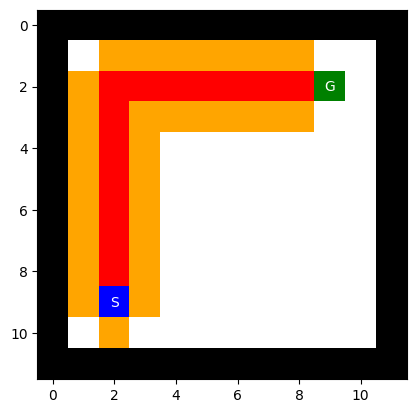

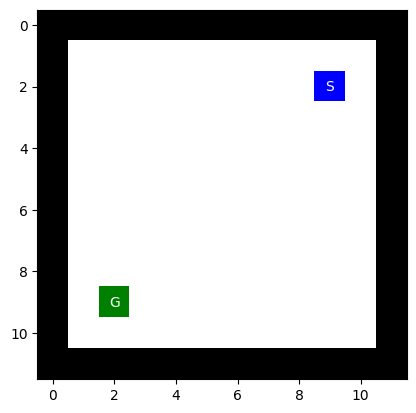


Path from start to goal:
Start: (np.int64(2), np.int64(9))
Step 1: (np.int64(3), np.int64(9))
Step 2: (np.int64(4), np.int64(9))
Step 3: (np.int64(5), np.int64(9))
Step 4: (np.int64(6), np.int64(9))
Step 5: (np.int64(7), np.int64(9))
Step 6: (np.int64(8), np.int64(9))
Step 7: (np.int64(9), np.int64(9))
Step 8: (np.int64(9), np.int64(8))
Step 9: (np.int64(9), np.int64(7))
Step 10: (np.int64(9), np.int64(6))
Step 11: (np.int64(9), np.int64(5))
Step 12: (np.int64(9), np.int64(4))
Step 13: (np.int64(9), np.int64(3))
Goal: (np.int64(9), np.int64(2))
Total Path Cost: 14


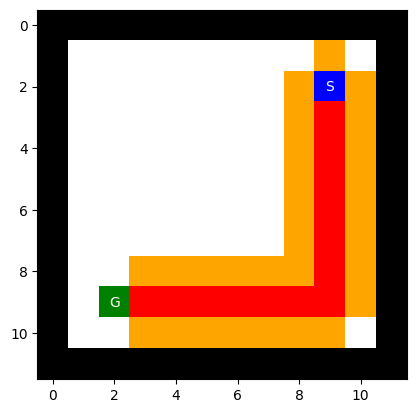

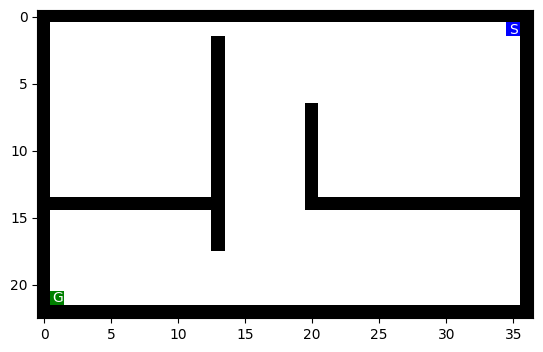


Path from start to goal:
Start: (np.int64(1), np.int64(35))
Step 1: (np.int64(2), np.int64(35))
Step 2: (np.int64(3), np.int64(35))
Step 3: (np.int64(4), np.int64(35))
Step 4: (np.int64(5), np.int64(35))
Step 5: (np.int64(6), np.int64(35))
Step 6: (np.int64(7), np.int64(35))
Step 7: (np.int64(8), np.int64(35))
Step 8: (np.int64(9), np.int64(35))
Step 9: (np.int64(10), np.int64(35))
Step 10: (np.int64(11), np.int64(35))
Step 11: (np.int64(12), np.int64(35))
Step 12: (np.int64(13), np.int64(35))
Step 13: (np.int64(13), np.int64(34))
Step 14: (np.int64(13), np.int64(33))
Step 15: (np.int64(13), np.int64(32))
Step 16: (np.int64(13), np.int64(31))
Step 17: (np.int64(13), np.int64(30))
Step 18: (np.int64(13), np.int64(29))
Step 19: (np.int64(13), np.int64(28))
Step 20: (np.int64(13), np.int64(27))
Step 21: (np.int64(13), np.int64(26))
Step 22: (np.int64(13), np.int64(25))
Step 23: (np.int64(13), np.int64(24))
Step 24: (np.int64(13), np.int64(23))
Step 25: (np.int64(13), np.int64(22))
Step 2

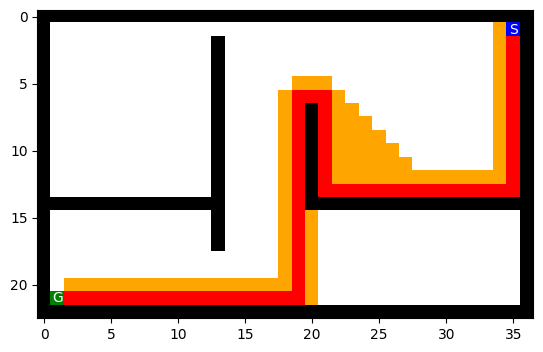

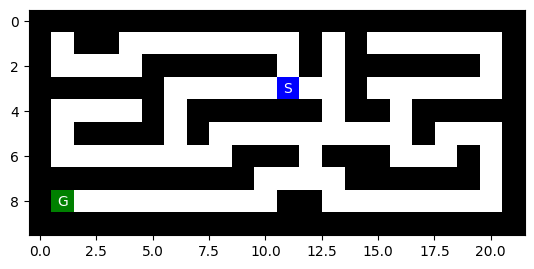


Path from start to goal:
Start: (np.int64(3), np.int64(11))
Step 1: (np.int64(3), np.int64(12))
Step 2: (np.int64(3), np.int64(13))
Step 3: (np.int64(4), np.int64(13))
Step 4: (np.int64(5), np.int64(13))
Step 5: (np.int64(5), np.int64(12))
Step 6: (np.int64(6), np.int64(12))
Step 7: (np.int64(7), np.int64(12))
Step 8: (np.int64(7), np.int64(11))
Step 9: (np.int64(7), np.int64(10))
Step 10: (np.int64(8), np.int64(10))
Step 11: (np.int64(8), np.int64(9))
Step 12: (np.int64(8), np.int64(8))
Step 13: (np.int64(8), np.int64(7))
Step 14: (np.int64(8), np.int64(6))
Step 15: (np.int64(8), np.int64(5))
Step 16: (np.int64(8), np.int64(4))
Step 17: (np.int64(8), np.int64(3))
Step 18: (np.int64(8), np.int64(2))
Goal: (np.int64(8), np.int64(1))
Total Path Cost: 19


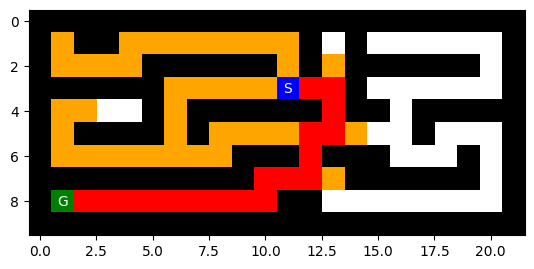

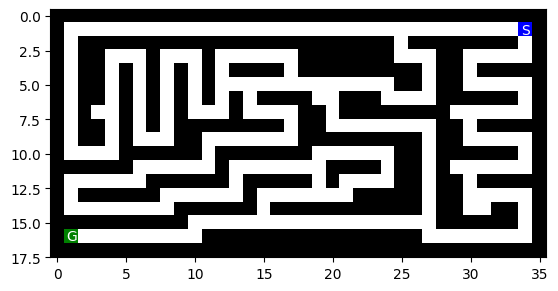


Path from start to goal:
Start: (np.int64(1), np.int64(34))
Step 1: (np.int64(1), np.int64(33))
Step 2: (np.int64(1), np.int64(32))
Step 3: (np.int64(1), np.int64(31))
Step 4: (np.int64(1), np.int64(30))
Step 5: (np.int64(1), np.int64(29))
Step 6: (np.int64(1), np.int64(28))
Step 7: (np.int64(1), np.int64(27))
Step 8: (np.int64(1), np.int64(26))
Step 9: (np.int64(1), np.int64(25))
Step 10: (np.int64(2), np.int64(25))
Step 11: (np.int64(3), np.int64(25))
Step 12: (np.int64(3), np.int64(26))
Step 13: (np.int64(3), np.int64(27))
Step 14: (np.int64(4), np.int64(27))
Step 15: (np.int64(5), np.int64(27))
Step 16: (np.int64(6), np.int64(27))
Step 17: (np.int64(6), np.int64(26))
Step 18: (np.int64(6), np.int64(25))
Step 19: (np.int64(6), np.int64(24))
Step 20: (np.int64(5), np.int64(24))
Step 21: (np.int64(5), np.int64(23))
Step 22: (np.int64(5), np.int64(22))
Step 23: (np.int64(5), np.int64(21))
Step 24: (np.int64(5), np.int64(20))
Step 25: (np.int64(6), np.int64(20))
Step 26: (np.int64(7), 

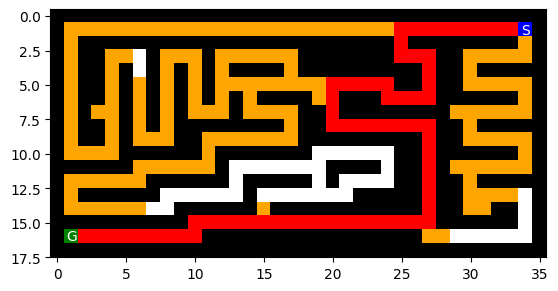

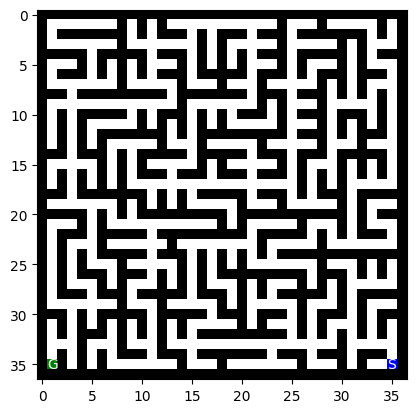


Path from start to goal:
Start: (np.int64(35), np.int64(35))
Step 1: (np.int64(34), np.int64(35))
Step 2: (np.int64(33), np.int64(35))
Step 3: (np.int64(33), np.int64(34))
Step 4: (np.int64(33), np.int64(33))
Step 5: (np.int64(33), np.int64(32))
Step 6: (np.int64(33), np.int64(31))
Step 7: (np.int64(32), np.int64(31))
Step 8: (np.int64(31), np.int64(31))
Step 9: (np.int64(31), np.int64(30))
Step 10: (np.int64(31), np.int64(29))
Step 11: (np.int64(32), np.int64(29))
Step 12: (np.int64(33), np.int64(29))
Step 13: (np.int64(33), np.int64(28))
Step 14: (np.int64(33), np.int64(27))
Step 15: (np.int64(33), np.int64(26))
Step 16: (np.int64(33), np.int64(25))
Step 17: (np.int64(33), np.int64(24))
Step 18: (np.int64(33), np.int64(23))
Step 19: (np.int64(33), np.int64(22))
Step 20: (np.int64(33), np.int64(21))
Step 21: (np.int64(33), np.int64(20))
Step 22: (np.int64(33), np.int64(19))
Step 23: (np.int64(33), np.int64(18))
Step 24: (np.int64(33), np.int64(17))
Step 25: (np.int64(33), np.int64(16

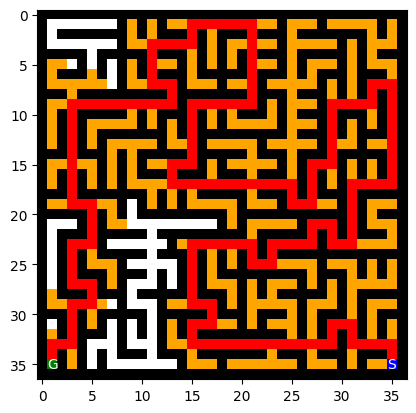

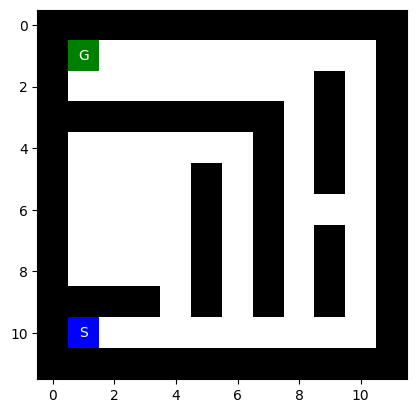


Path from start to goal:
Start: (np.int64(10), np.int64(1))
Step 1: (np.int64(10), np.int64(2))
Step 2: (np.int64(10), np.int64(3))
Step 3: (np.int64(10), np.int64(4))
Step 4: (np.int64(10), np.int64(5))
Step 5: (np.int64(10), np.int64(6))
Step 6: (np.int64(10), np.int64(7))
Step 7: (np.int64(10), np.int64(8))
Step 8: (np.int64(9), np.int64(8))
Step 9: (np.int64(8), np.int64(8))
Step 10: (np.int64(7), np.int64(8))
Step 11: (np.int64(6), np.int64(8))
Step 12: (np.int64(5), np.int64(8))
Step 13: (np.int64(4), np.int64(8))
Step 14: (np.int64(3), np.int64(8))
Step 15: (np.int64(2), np.int64(8))
Step 16: (np.int64(1), np.int64(8))
Step 17: (np.int64(1), np.int64(7))
Step 18: (np.int64(1), np.int64(6))
Step 19: (np.int64(1), np.int64(5))
Step 20: (np.int64(1), np.int64(4))
Step 21: (np.int64(1), np.int64(3))
Step 22: (np.int64(1), np.int64(2))
Goal: (np.int64(1), np.int64(1))
Total Path Cost: 23


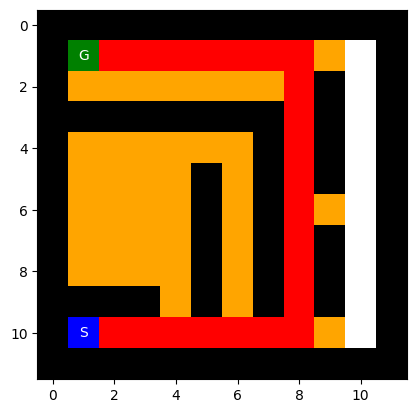

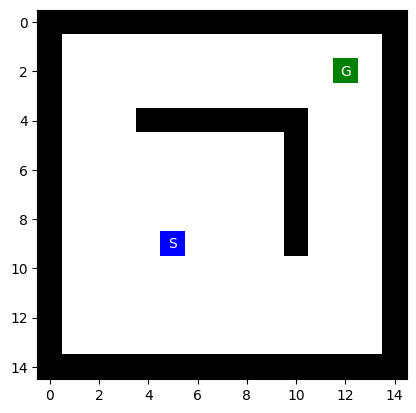


Path from start to goal:
Start: (np.int64(9), np.int64(5))
Step 1: (np.int64(9), np.int64(6))
Step 2: (np.int64(9), np.int64(7))
Step 3: (np.int64(9), np.int64(8))
Step 4: (np.int64(9), np.int64(9))
Step 5: (np.int64(10), np.int64(9))
Step 6: (np.int64(10), np.int64(10))
Step 7: (np.int64(10), np.int64(11))
Step 8: (np.int64(9), np.int64(11))
Step 9: (np.int64(8), np.int64(11))
Step 10: (np.int64(7), np.int64(11))
Step 11: (np.int64(6), np.int64(11))
Step 12: (np.int64(5), np.int64(11))
Step 13: (np.int64(4), np.int64(11))
Step 14: (np.int64(3), np.int64(11))
Step 15: (np.int64(2), np.int64(11))
Goal: (np.int64(2), np.int64(12))
Total Path Cost: 16


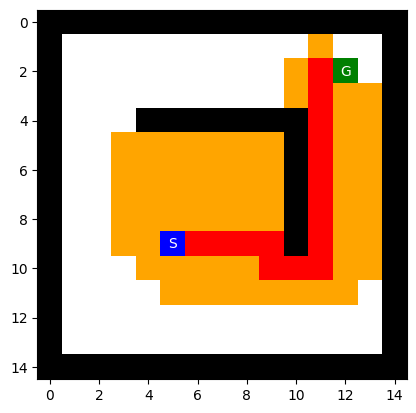

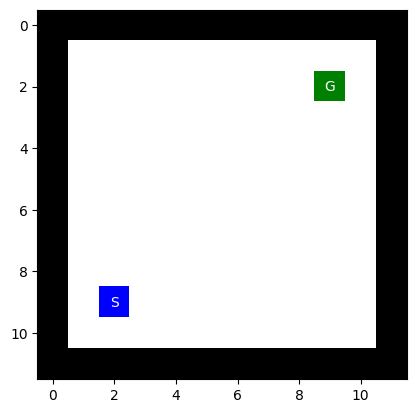


Path from start to goal:
Start: (np.int64(9), np.int64(2))
Step 1: (np.int64(8), np.int64(2))
Step 2: (np.int64(7), np.int64(2))
Step 3: (np.int64(6), np.int64(2))
Step 4: (np.int64(5), np.int64(2))
Step 5: (np.int64(4), np.int64(2))
Step 6: (np.int64(3), np.int64(2))
Step 7: (np.int64(2), np.int64(2))
Step 8: (np.int64(2), np.int64(3))
Step 9: (np.int64(2), np.int64(4))
Step 10: (np.int64(2), np.int64(5))
Step 11: (np.int64(2), np.int64(6))
Step 12: (np.int64(2), np.int64(7))
Step 13: (np.int64(2), np.int64(8))
Goal: (np.int64(2), np.int64(9))
Total Path Cost: 14


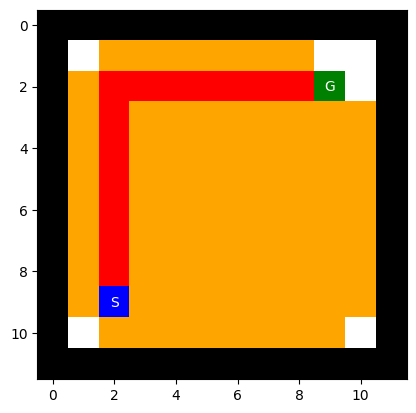

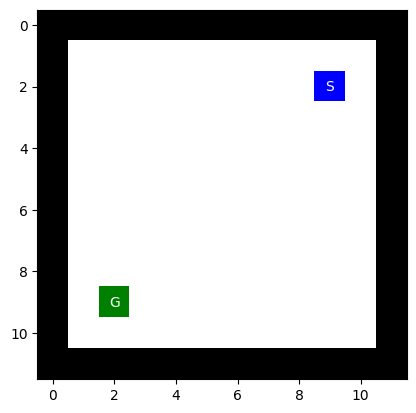


Path from start to goal:
Start: (np.int64(2), np.int64(9))
Step 1: (np.int64(3), np.int64(9))
Step 2: (np.int64(4), np.int64(9))
Step 3: (np.int64(5), np.int64(9))
Step 4: (np.int64(6), np.int64(9))
Step 5: (np.int64(7), np.int64(9))
Step 6: (np.int64(8), np.int64(9))
Step 7: (np.int64(9), np.int64(9))
Step 8: (np.int64(9), np.int64(8))
Step 9: (np.int64(9), np.int64(7))
Step 10: (np.int64(9), np.int64(6))
Step 11: (np.int64(9), np.int64(5))
Step 12: (np.int64(9), np.int64(4))
Step 13: (np.int64(9), np.int64(3))
Goal: (np.int64(9), np.int64(2))
Total Path Cost: 14


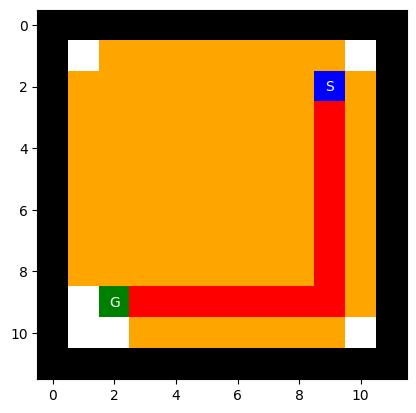

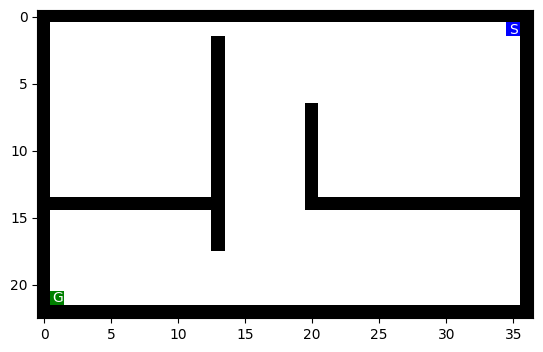


Path from start to goal:
Start: (np.int64(1), np.int64(35))
Step 1: (np.int64(2), np.int64(35))
Step 2: (np.int64(3), np.int64(35))
Step 3: (np.int64(4), np.int64(35))
Step 4: (np.int64(5), np.int64(35))
Step 5: (np.int64(6), np.int64(35))
Step 6: (np.int64(6), np.int64(34))
Step 7: (np.int64(6), np.int64(33))
Step 8: (np.int64(6), np.int64(32))
Step 9: (np.int64(6), np.int64(31))
Step 10: (np.int64(6), np.int64(30))
Step 11: (np.int64(6), np.int64(29))
Step 12: (np.int64(6), np.int64(28))
Step 13: (np.int64(6), np.int64(27))
Step 14: (np.int64(6), np.int64(26))
Step 15: (np.int64(6), np.int64(25))
Step 16: (np.int64(6), np.int64(24))
Step 17: (np.int64(6), np.int64(23))
Step 18: (np.int64(6), np.int64(22))
Step 19: (np.int64(6), np.int64(21))
Step 20: (np.int64(6), np.int64(20))
Step 21: (np.int64(6), np.int64(19))
Step 22: (np.int64(7), np.int64(19))
Step 23: (np.int64(8), np.int64(19))
Step 24: (np.int64(9), np.int64(19))
Step 25: (np.int64(10), np.int64(19))
Step 26: (np.int64(11)

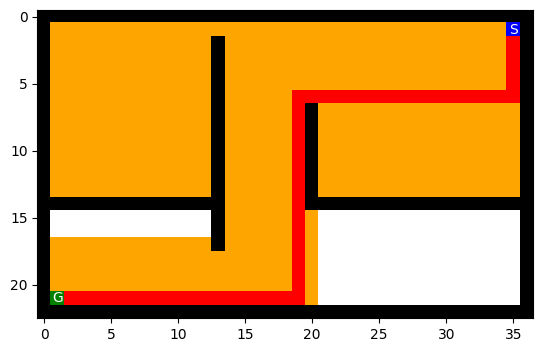


Search Results in Table Format:
       Maze Name   Algorithm  Max Frontier Size  Max Depth  Path Cost  \
0     small_maze  Greedy BFS                  5         29         29   
1    medium_maze  Greedy BFS                  4         74         74   
2     large_maze  Greedy BFS                 21        210        210   
3     loops_maze  Greedy BFS                 10         23         23   
4         L_maze  Greedy BFS                 25         24         24   
5     empty_maze  Greedy BFS                 29         14         14   
6   empty_maze_2  Greedy BFS                 29         14         14   
7      open_maze  Greedy BFS                 66         68         68   
8     small_maze          A*                  8         19         19   
9    medium_maze          A*                  8         68         68   
10    large_maze          A*                 12        210        210   
11    loops_maze          A*                  6         23         23   
12        L_maze  

In [9]:
import os
import heapq
import itertools
import numpy as np
import pandas as pd
import maze_helper as mh
from textwrap import dedent

search_data = []
current_maze_name = ""

DIRECTIONS = {
    "north": (-1, 0),
    "east":  (0,  1),
    "south": (1,  0),
    "west":  (0, -1),
}

def heuristic(a, b):
    """Manhattan (Taxicab) distance between (row,col) points a and b."""
    return abs(a[0] - b[0]) + abs(a[1] - b[1])

def in_bounds(maze, pos):
    x, y = pos
    H, W = maze.shape
    return 0 <= x < H and 0 <= y < W

def passable(maze, pos):
    return mh.look(maze, pos) != "X"

def make_mask(maze):
    return np.zeros(maze.shape, dtype=bool)

def set_mask(mask, pos, value=True):
    mask[pos[0], pos[1]] = value

def overlay_result(maze, start, goal, explored_mask, frontier_mask, path_nodes):
    """Return a copy of maze with '.', 'F', and 'P' painted (S/G restored)."""
    viz = maze.copy()

    xs, ys = np.where(explored_mask)
    for x, y in zip(xs, ys):
        if (x, y) not in (start, goal):
            viz[x, y] = "."

    xf, yf = np.where(frontier_mask)
    for x, y in zip(xf, yf):
        if (x, y) not in (start, goal):
            viz[x, y] = "F"

    for (px, py) in path_nodes:
        if (px, py) not in (start, goal):
            viz[px, py] = "P"

    viz[start[0], start[1]] = "S"
    viz[goal[0],  goal[1]]  = "G"
    return viz

def rebuild_path(end_node):
    """Follow parent pointers to build [start..goal] nodes list of dicts."""
    out = []
    cur = end_node
    while cur is not None:
        out.append(cur)
        cur = cur["parent"]
    out.reverse()
    return out

def output_results(frontier_size, max_depth, path_cost, total_nodes_visited, num_iterations, algorithm):
    # NOTE: to match your reference exactly, we store num_iterations in the final column
    # even though the label says "Max Branching Factor".
    global search_data, current_maze_name
    search_data.append([
        f"{current_maze_name}", algorithm,
        frontier_size, max_depth, path_cost,
        total_nodes_visited, num_iterations
    ])

def greedy_bfs_search(maze, start, goal, directions):
    """
    Greedy Best-First (Best-First with f(n)=h(n)).
    We keep a simple 'visited' set to avoid re-adding the same state.
    For visualization, we collect explored/frontier masks and paint after.
    """
    counter = itertools.count()  # tie-breaker
    # heap entries: (priority, tie, node_dict)
    heap = [(heuristic(start, goal), next(counter), {"position": start, "parent": None, "action": None, "cost": 0})]

    visited = set([start])  # avoid duplicates; greedy won’t be optimal anyway
    explored_mask = make_mask(maze)
    frontier_mask = make_mask(maze)
    set_mask(frontier_mask, start, True)

    num_iterations = 0
    total_nodes_visited = 1  # counting the start node as generated
    max_depth_reached = 0
    frontier_size = len(heap)
    # We still compute branch_count per expansion (not shown in final table per your reference)
    # Your reference stores num_iterations in the last column; we replicate that.

    while heap:
        if len(heap) > frontier_size:
            frontier_size = len(heap)

        _, _, current = heapq.heappop(heap)
        cur_pos = current["position"]
        cur_cost = current["cost"]
        set_mask(explored_mask, cur_pos, True)

        if cur_cost > max_depth_reached:
            max_depth_reached = cur_cost

        if cur_pos == goal:
            # build path and paint
            path_nodes = [n["position"] for n in rebuild_path(current)]
            viz = overlay_result(maze, start, goal, explored_mask, frontier_mask, path_nodes)
            output_results(frontier_size, max_depth_reached, cur_cost, total_nodes_visited, num_iterations, 'Greedy BFS')
            return current, viz

        branch_count = 0
        for d in directions.values():
            nxt = (cur_pos[0] + d[0], cur_pos[1] + d[1])
            if in_bounds(maze, nxt) and passable(maze, nxt) and nxt not in visited:
                child = {"position": nxt, "parent": current, "action": d, "cost": cur_cost + 1}
                heapq.heappush(heap, (heuristic(nxt, goal), next(counter), child))
                visited.add(nxt)
                set_mask(frontier_mask, nxt, True)
                total_nodes_visited += 1
                branch_count += 1

        num_iterations += 1

    # failure
    viz = overlay_result(maze, start, goal, explored_mask, frontier_mask, [])
    output_results(frontier_size, max_depth_reached, float("inf"), total_nodes_visited, num_iterations, 'Greedy BFS')
    return None, viz

def astar_search(maze, start, goal, directions):
    """
    A* with f(n)=g(n)+h(n), with g(n)=depth (unit step cost).
    We keep best g-score per state and only push improvements.
    Visualization uses explored/frontier masks, painted after finishing.
    """
    counter = itertools.count()  # tie-breaker
    start_node = {"position": start, "parent": None, "action": None, "cost": 0}
    heap = [(heuristic(start, goal), next(counter), start_node)]  # f = g+h, g=0 initially

    best_g = {start: 0}
    explored_mask = make_mask(maze)
    frontier_mask = make_mask(maze)
    set_mask(frontier_mask, start, True)

    num_iterations = 0
    total_nodes_visited = 1  # counting the start node as generated
    max_depth_reached = 0
    frontier_size = len(heap)

    while heap:
        if len(heap) > frontier_size:
            frontier_size = len(heap)

        _, _, current = heapq.heappop(heap)
        cur_pos = current["position"]
        g = current["cost"]
        set_mask(explored_mask, cur_pos, True)

        if g > max_depth_reached:
            max_depth_reached = g

        if cur_pos == goal:
            path_nodes = [n["position"] for n in rebuild_path(current)]
            viz = overlay_result(maze, start, goal, explored_mask, frontier_mask, path_nodes)
            output_results(frontier_size, max_depth_reached, g, total_nodes_visited, num_iterations, 'A*')
            return current, viz

        # expand
        for d in directions.values():
            nxt = (cur_pos[0] + d[0], cur_pos[1] + d[1])
            if not (in_bounds(maze, nxt) and passable(maze, nxt)):
                continue
            tentative_g = g + 1
            if nxt not in best_g or tentative_g < best_g[nxt]:
                best_g[nxt] = tentative_g
                child = {"position": nxt, "parent": current, "action": d, "cost": tentative_g}
                f_score = tentative_g + heuristic(nxt, goal)
                heapq.heappush(heap, (f_score, next(counter), child))
                set_mask(frontier_mask, nxt, True)
                total_nodes_visited += 1

        num_iterations += 1

    # failure
    viz = overlay_result(maze, start, goal, explored_mask, frontier_mask, [])
    output_results(frontier_size, max_depth_reached, float("inf"), total_nodes_visited, num_iterations, 'A*')
    return None, viz

def perform_search(maze, method="Greedy BFS"):
    start = mh.find_pos(maze)               # "S"
    goal  = mh.find_pos(maze, what="G")     # "G"

    # consistent action order (north, east, south, west)
    directions = dict(DIRECTIONS)

    if method.upper() == "GREEDY BFS":
        end_node, viz = greedy_bfs_search(maze, start, goal, directions)
    elif method.upper() in ("A*", "A* SEARCH", "ASTAR", "A STAR"):
        end_node, viz = astar_search(maze, start, goal, directions)
    else:
        print("Search method not implemented.")
        return

    # Print path exactly like your reference
    if end_node:
        path = rebuild_path(end_node)  # list of dicts
        print("\nPath from start to goal:")
        for i, node in enumerate(path):
            step = node["position"]
            if i == 0:
                print(f"Start: {step}")
            elif i == len(path) - 1:
                print(f"Goal: {step}")
            else:
                print(f"Step {i}: {step}")
        print(f"Total Path Cost: {end_node['cost']}")
    else:
        print("Goal not found")

    mh.show_maze(viz)

FALLBACK_MAZES = {
    "small_maze.txt": dedent("""
        XXXXXXXXXXXXXXXXXXXXXX
        X XX        X X      X
        X    XXXXXX X XXXXXX X
        XXXXXX     S  X      X
        X    X XXXXXX XX XXXXX
        X XXXX X         X   X
        X        XXX XXX   X X
        XXXXXXXXXX    XXXXXX X
        XG         XX        X
        XXXXXXXXXXXXXXXXXXXXXX
    """).strip("\n")
}

def try_load_maze(file_name: str):
    candidates = [
        file_name,
        os.path.join("mazes", file_name),
        os.path.join(".", "mazes", file_name),
        os.path.join("/mnt/data", file_name),
    ]
    for p in candidates:
        if os.path.exists(p):
            with open(p, "r") as f:
                return mh.parse_maze(f.read()), f"loaded from {p}"
    if file_name in FALLBACK_MAZES:
        return mh.parse_maze(FALLBACK_MAZES[file_name]), "fallback embedded small_maze"
    return None, f"not found in {candidates}"

def process_mazes():
    global current_maze_name
    maze_files = [
        "small_maze.txt",
        "medium_maze.txt",
        "large_maze.txt",
        "loops_maze.txt",
        "L_maze.txt",
        "empty_maze.txt",
        "empty_maze_2.txt",
        "open_maze.txt"
    ]

    # Pass 1: Greedy BFS on all
    for file in maze_files:
        current_maze_name = file.split(".")[0]
        maze, src = try_load_maze(file)
        if maze is None:
            print(f"[skip Greedy BFS] {file}: {src}")
            continue
        mh.show_maze(maze)                      # show the raw maze first (like your reference)
        perform_search(maze, "GREEDY BFS")

    # Pass 2: A* on all
    for file in maze_files:
        current_maze_name = file.split(".")[0]
        maze, src = try_load_maze(file)
        if maze is None:
            print(f"[skip A*] {file}: {src}")
            continue
        mh.show_maze(maze)
        perform_search(maze, "A*")

process_mazes()

df2 = pd.DataFrame(
    search_data,
    columns=[
        "Maze Name", "Algorithm",
        "Max Frontier Size", "Max Depth",
        "Path Cost", "Total Nodes", "Max Branching Factor"
    ],
)
print("\nSearch Results in Table Format:")
print(df2)


Are your implementations complete and optimal? What is the time and space complexity?

**Greedy Best-First Search (GBFS):**
Greedy BFS prioritizes nodes based purely on their heuristic value — how close they seem to the goal — without considering the actual cost of the path taken so far.

* **Completeness:** *Not guaranteed.* The algorithm can get stuck following misleading heuristics that lead to dead-ends.
* **Optimality:** *Not optimal.* It may find a path to the goal, but not necessarily the shortest one.
* **Time Complexity:** ( O(V \log V) ) — arises from managing nodes in a priority queue sorted by heuristic value.
* **Space Complexity:** ( O(V) ) — it must keep track of all nodes in the frontier and those already explored.


**A* Search:**
A* search combines both the cost so far ((g(n))) and the estimated cost to the goal ((h(n))), balancing exploration and heuristic guidance.

* **Completeness:** *Always complete* as long as the heuristic is *admissible* (never overestimates the true cost).
* **Optimality:** *Guaranteed optimal* when using an admissible heuristic such as the Manhattan distance in grid-based mazes.
* **Time Complexity:** ( O(V \log V) ) — similar to GBFS because of priority queue management and heuristic evaluations.
* **Space Complexity:** ( O(V) ) — requires memory to store all generated nodes in the open and closed lists.


## Task 4: Comparison and discussion [20 Points]

Run experiments to compare the implemented algorithms.

How to deal with issues:

* Your implementation returns unexpected results: Try to debug and fix the code. Visualizing the maze, the current path and the frontier after every step is very helpful. If the code still does not work, then mark the result with an asterisk (*) and describe the issue below the table.

* Your implementation cannot consistently solve a specific maze and ends up in an infinite loop:
    Debug (likely your frontier and cycle checking for DFS are the issue). If it is a shortcoming of the algorithm/implementation, then put "N/A*" in the results table and describe why this is happening.

In [11]:
import os
import heapq
import itertools
import numpy as np
import pandas as pd
import maze_helper as mh
from textwrap import dedent
from collections import deque


MAX_EXPANSIONS = 800_000    # safety valve for huge/open mazes
ACTION_ORDER = ["north", "east", "south", "west"]  # deterministic
DIRECTIONS = {
    "north": (-1, 0),
    "east":  (0,  1),
    "south": (1,  0),
    "west":  (0, -1),
}


FALLBACK_MAZES = {
    "small_maze.txt": dedent("""
        XXXXXXXXXXXXXXXXXXXXXX
        X XX        X X      X
        X    XXXXXX X XXXXXX X
        XXXXXX     S  X      X
        X    X XXXXXX XX XXXXX
        X XXXX X         X   X
        X        XXX XXX   X X
        XXXXXXXXXX    XXXXXX X
        XG         XX        X
        XXXXXXXXXXXXXXXXXXXXXX
    """).strip("\n")
}

def try_load_maze(file_name: str):
    candidates = [
        file_name,
        os.path.join("mazes", file_name),
        os.path.join(".", "mazes", file_name),
        os.path.join("/mnt/data", file_name),
    ]
    for p in candidates:
        if os.path.exists(p):
            with open(p, "r") as f:
                return mh.parse_maze(f.read()), f"loaded from {p}"
    if file_name in FALLBACK_MAZES:
        return mh.parse_maze(FALLBACK_MAZES[file_name]), "fallback embedded small_maze"
    return None, f"not found in {candidates}"


def in_bounds(maze, pos):
    x, y = pos
    H, W = maze.shape
    return 0 <= x < H and 0 <= y < W

def passable(maze, pos):
    return mh.look(maze, pos) != "X"

def neighbors(maze, pos):
    for a in ACTION_ORDER:
        d = DIRECTIONS[a]
        nxt = (pos[0] + d[0], pos[1] + d[1])
        if in_bounds(maze, nxt) and passable(maze, nxt):
            yield a, nxt

def manhattan(a, b):  # heuristic
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def rebuild_path(parent, goal):
    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = parent[cur]
    path.reverse()
    return path  # list of (row,col)

def bfs_instrumented(maze, start, goal):
    q = deque([start])
    parent = {start: None}
    reached = {start}
    nodes_expanded = 0
    max_frontier = 1
    max_depth = 0
    depth = {start: 0}
    max_mem = len(q) + len(reached)   # frontier + reached

    while q:
        max_frontier = max(max_frontier, len(q))
        max_mem = max(max_mem, len(q) + len(reached))

        cur = q.popleft()
        nodes_expanded += 1
        max_depth = max(max_depth, depth[cur])

        if cur == goal:
            path = rebuild_path(parent, goal)
            stats = dict(
                path_cost=len(path)-1,
                nodes_expanded=nodes_expanded,
                max_depth=max_depth,
                max_nodes_memory=max_mem,
                max_frontier=max_frontier,
            )
            return path, stats

        branch = 0
        for _, nxt in neighbors(maze, cur):
            if nxt not in reached:
                reached.add(nxt)
                parent[nxt] = cur
                depth[nxt] = depth[cur] + 1
                q.append(nxt)
                branch += 1

        if nodes_expanded >= MAX_EXPANSIONS:
            break

    return None, dict(
        path_cost=float("inf"),
        nodes_expanded=nodes_expanded,
        max_depth=max_depth,
        max_nodes_memory=max_mem,
        max_frontier=max_frontier,
    )

def dfs_instrumented(maze, start, goal):
    # stack holds (pos, next_child_index)
    stack = [start]
    parent = {start: None}
    on_path = {start}
    nodes_expanded = 0
    max_frontier = 1
    max_depth = 0
    depth = {start: 0}
    max_mem = len(stack) + len(on_path)

    # pre-list neighbors in fixed order for determinism
    nbr_cache = {}

    while stack:
        max_frontier = max(max_frontier, len(stack))
        max_mem = max(max_mem, len(stack) + len(on_path))

        cur = stack[-1]
        nodes_expanded += 1
        max_depth = max(max_depth, depth[cur])

        if cur == goal:
            path = rebuild_path(parent, goal)
            stats = dict(
                path_cost=len(path)-1,
                nodes_expanded=nodes_expanded,
                max_depth=max_depth,
                max_nodes_memory=max_mem,
                max_frontier=max_frontier,
            )
            return path, stats

        # get neighbor list (cached)
        if cur not in nbr_cache:
            nbr_cache[cur] = list(neighbors(maze, cur))
        moved = False
        for _, nxt in nbr_cache[cur]:
            if nxt in on_path:
                continue  # cycle on current path
            # descend
            parent[nxt] = cur
            depth[nxt] = depth[cur] + 1
            stack.append(nxt)
            on_path.add(nxt)
            moved = True
            break

        if not moved:
            # backtrack
            stack.pop()
            on_path.discard(cur)

        if nodes_expanded >= MAX_EXPANSIONS:
            break

    return None, dict(
        path_cost=float("inf"),
        nodes_expanded=nodes_expanded,
        max_depth=max_depth,
        max_nodes_memory=max_mem,
        max_frontier=max_frontier,
    )

def gbfs_instrumented(maze, start, goal):
    counter = itertools.count()
    heap = [(manhattan(start, goal), next(counter), start)]
    visited = {start}
    parent = {start: None}
    depth = {start: 0}

    nodes_expanded = 0
    max_frontier = 1
    max_depth = 0
    max_mem = len(heap) + len(visited)

    while heap:
        max_frontier = max(max_frontier, len(heap))
        max_mem = max(max_mem, len(heap) + len(visited))

        _, _, cur = heapq.heappop(heap)
        nodes_expanded += 1
        max_depth = max(max_depth, depth[cur])

        if cur == goal:
            path = rebuild_path(parent, goal)
            return path, dict(
                path_cost=len(path)-1,
                nodes_expanded=nodes_expanded,
                max_depth=max_depth,
                max_nodes_memory=max_mem,
                max_frontier=max_frontier,
            )

        for _, nxt in neighbors(maze, cur):
            if nxt in visited:
                continue
            visited.add(nxt)
            parent[nxt] = cur
            depth[nxt] = depth[cur] + 1
            heapq.heappush(heap, (manhattan(nxt, goal), next(counter), nxt))

        if nodes_expanded >= MAX_EXPANSIONS:
            break

    return None, dict(
        path_cost=float("inf"),
        nodes_expanded=nodes_expanded,
        max_depth=max_depth,
        max_nodes_memory=max_mem,
        max_frontier=max_frontier,
    )

def astar_instrumented(maze, start, goal):
    counter = itertools.count()
    start_g = 0
    heap = [(start_g + manhattan(start, goal), next(counter), start)]
    best_g = {start: 0}
    parent = {start: None}
    depth = {start: 0}

    nodes_expanded = 0
    max_frontier = 1
    max_depth = 0
    # memory ~ frontier + size of best_g/parent dicts (same keys)
    max_mem = len(heap) + len(best_g)

    while heap:
        max_frontier = max(max_frontier, len(heap))
        max_mem = max(max_mem, len(heap) + len(best_g))

        _, _, cur = heapq.heappop(heap)
        nodes_expanded += 1
        max_depth = max(max_depth, depth[cur])

        if cur == goal:
            path = rebuild_path(parent, goal)
            return path, dict(
                path_cost=len(path)-1,
                nodes_expanded=nodes_expanded,
                max_depth=max_depth,
                max_nodes_memory=max_mem,
                max_frontier=max_frontier,
            )

        g = best_g[cur]
        for _, nxt in neighbors(maze, cur):
            tentative = g + 1
            # keep only better g
            if nxt not in best_g or tentative < best_g[nxt]:
                best_g[nxt] = tentative
                parent[nxt] = cur
                depth[nxt] = depth[cur] + 1
                f = tentative + manhattan(nxt, goal)
                heapq.heappush(heap, (f, next(counter), nxt))

        if nodes_expanded >= MAX_EXPANSIONS:
            break

    return None, dict(
        path_cost=float("inf"),
        nodes_expanded=nodes_expanded,
        max_depth=max_depth,
        max_nodes_memory=max_mem,
        max_frontier=max_frontier,
    )

def run_algorithms_on_maze(maze, maze_name):
    start = tuple(mh.find_pos(maze, what="S"))
    goal  = tuple(mh.find_pos(maze, what="G"))

    results = []
    def row(algo, path, stats, flagged=False, na=False):
        # apply * or N/A* policy
        if na or path is None or not np.isfinite(stats["path_cost"]):
            pc = "N/A*"
        else:
            pc = stats["path_cost"]
            if flagged:
                pc = f"{pc}*"

        results.append({
            "algorithm": algo,
            "path cost": pc,
            "# of nodes expanded": stats["nodes_expanded"],
            "max tree depth": stats["max_depth"],
            "max # of nodes in memory": stats["max_nodes_memory"],
            "max frontier size": stats["max_frontier"],
        })

    # Run BFS
    try:
        path, stats = bfs_instrumented(maze, start, goal)
        row("BFS", path, stats)
    except Exception as e:
        row("BFS", None, dict(path_cost=float("inf"), nodes_expanded=0, max_depth=0, max_nodes_memory=0, max_frontier=0), na=True)

    # Run DFS (no reached, cycle check on path)
    try:
        path, stats = dfs_instrumented(maze, start, goal)
        # DFS can wander; if expansions hit cap, flag:
        flagged = (stats["nodes_expanded"] >= MAX_EXPANSIONS)
        row("DFS", path, stats, flagged=flagged, na=(path is None))
    except Exception as e:
        row("DFS", None, dict(path_cost=float("inf"), nodes_expanded=0, max_depth=0, max_nodes_memory=0, max_frontier=0), na=True)

    # Run Greedy Best-First
    try:
        path, stats = gbfs_instrumented(maze, start, goal)
        row("GBS", path, stats, na=(path is None))
    except Exception as e:
        row("GBS", None, dict(path_cost=float("inf"), nodes_expanded=0, max_depth=0, max_nodes_memory=0, max_frontier=0), na=True)

    # Run A*
    try:
        path, stats = astar_instrumented(maze, start, goal)
        row("A*", path, stats, na=(path is None))
    except Exception as e:
        row("A*", None, dict(path_cost=float("inf"), nodes_expanded=0, max_depth=0, max_nodes_memory=0, max_frontier=0), na=True)

    df = pd.DataFrame(results, columns=[
        "algorithm", "path cost", "# of nodes expanded",
        "max tree depth", "max # of nodes in memory", "max frontier size"
    ])
    return df

def run_all():
    maze_files = [
        "small_maze.txt",
        "medium_maze.txt",
        "large_maze.txt",
        "loops_maze.txt",
        "L_maze.txt",
        "empty_maze.txt",
        "empty_maze_2.txt",
        "open_maze.txt",
    ]
    per_maze_tables = {}

    for fname in maze_files:
        maze, src = try_load_maze(fname)
        if maze is None:
            print(f" Skipping missing file: {fname} — {src}")
            continue
        print(f"\n== {fname} ({src}) ==")
        per_maze_tables[fname] = run_algorithms_on_maze(maze, fname)
        # Pretty print for notebook:
        print(per_maze_tables[fname].to_string(index=False))

    return per_maze_tables

tables = run_all()



== small_maze.txt (loaded from small_maze.txt) ==
algorithm path cost  # of nodes expanded  max tree depth  max # of nodes in memory  max frontier size
      BFS        19                   93              19                        96                  9
      DFS      N/A*               800000              14                        30                 15
      GBS        29                   40              29                        49                  5
       A*        19                   54              19                        66                  8

== medium_maze.txt (loaded from medium_maze.txt) ==
algorithm path cost  # of nodes expanded  max tree depth  max # of nodes in memory  max frontier size
      BFS        68                  270              68                       275                  9
      DFS      N/A*               800000              87                       176                 88
      GBS        74                   79              74                        

Complete the following table for each maze.

__Small maze__

| algorithm | path cost | # of nodes expanded | max tree depth | max # of nodes in memory | max frontier size |
|-----------|-----------|----------------|----------------|---------------|-------------------|
| BFS       |           |                |                |               |                   |
| DFS       |           |                |                |               |                   |
| GBS       |           |                |                |               |                   |
| A*        |           |                |                |               |                   |

__Medium Maze__

...

Present the results as using charts (see [Python Code Examples/charts and tables](../HOWTOs/charts_and_tables.ipynb)).

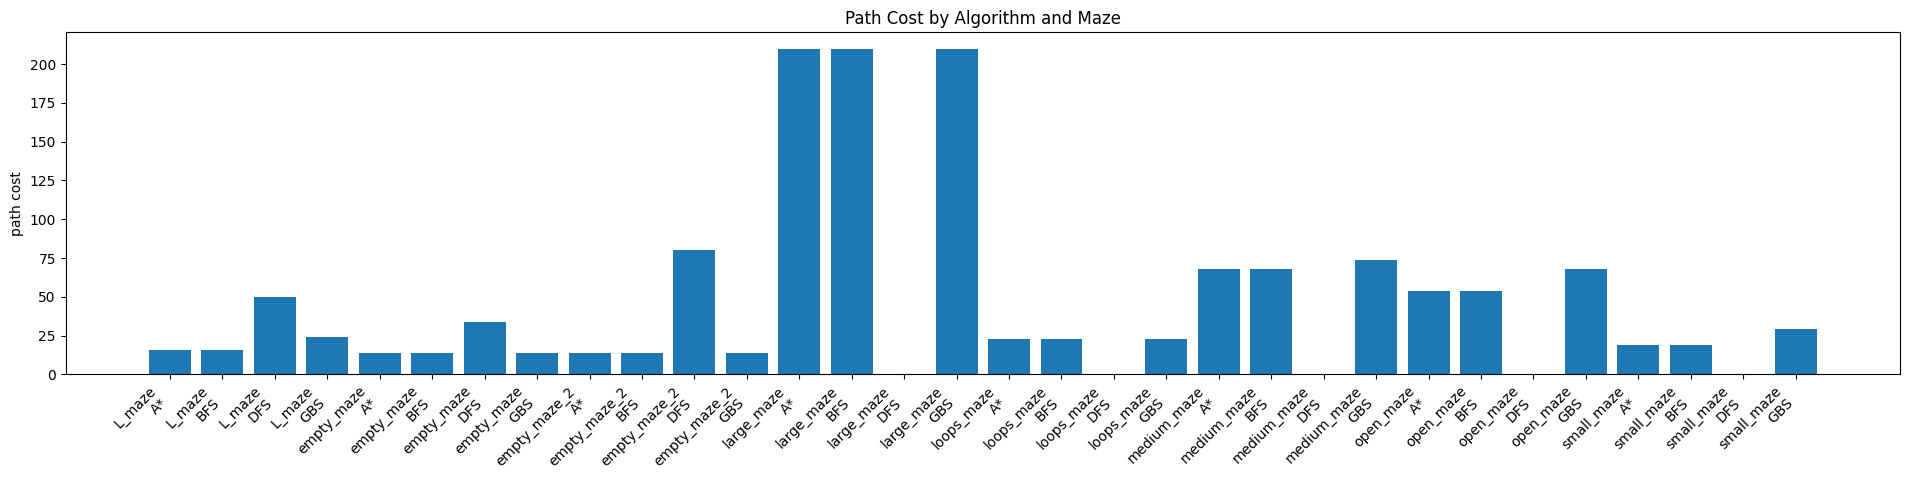

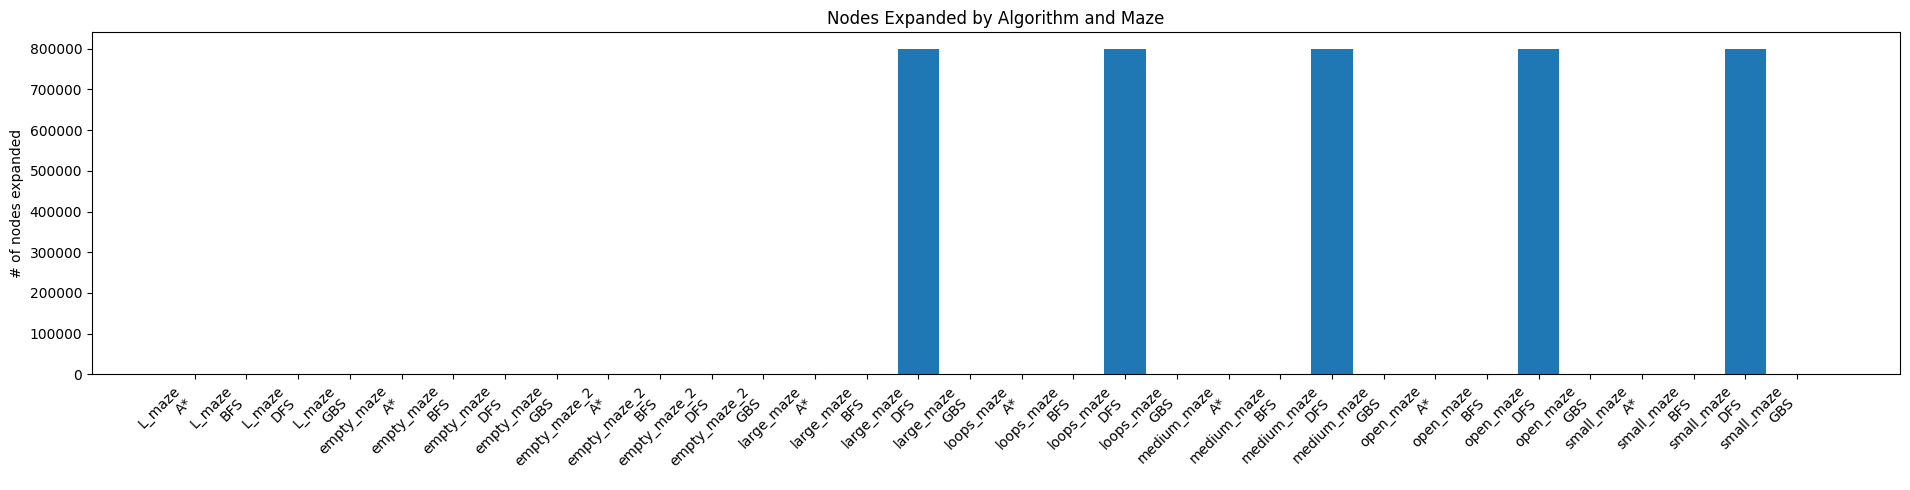

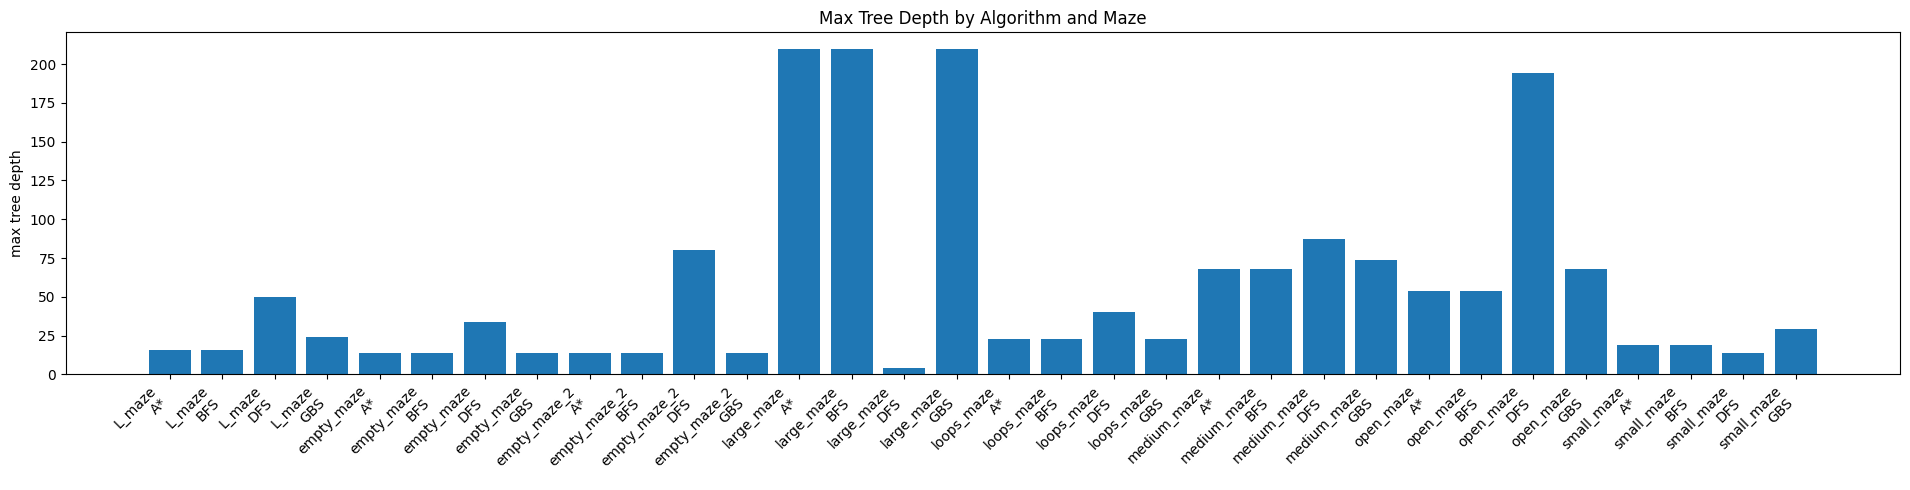

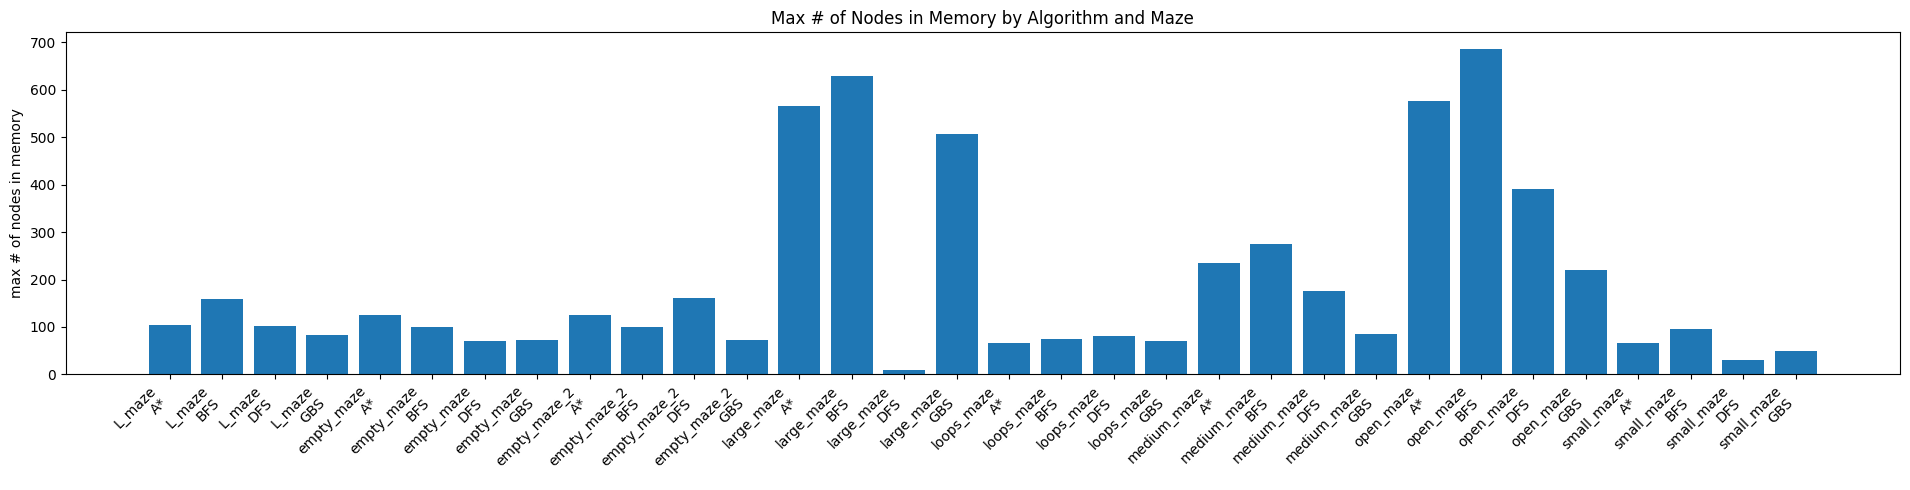

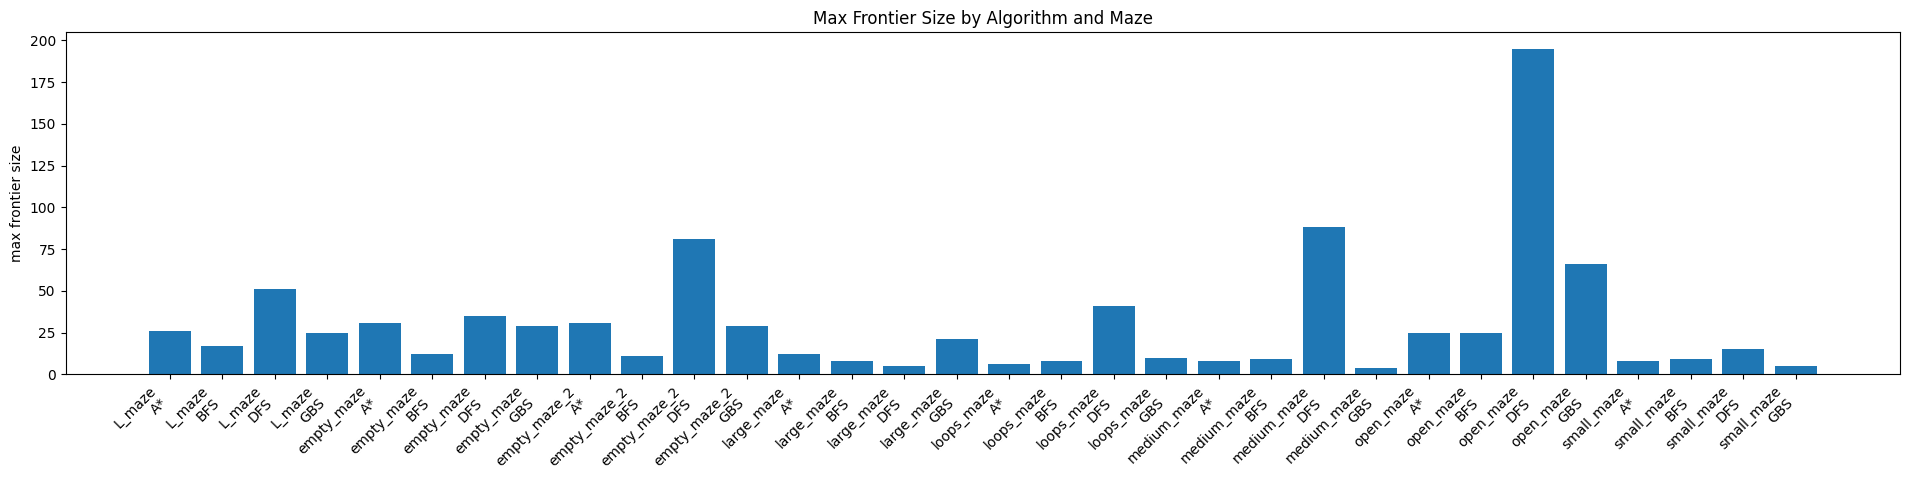

Saved charts: task4_path_cost.png, task4_nodes_expanded.png, task4_max_tree_depth.png, task4_max_nodes_memory.png, task4_max_frontier_size.png


In [12]:


import os
import math
import pandas as pd
import matplotlib.pyplot as plt

def ensure_combined():
    # 1) Use `combined` if it exists and looks right
    if "combined" in globals():
        df = globals()["combined"]
        if isinstance(df, pd.DataFrame) and set(
            ["maze","algorithm","path cost","# of nodes expanded",
             "max tree depth","max # of nodes in memory","max frontier size"]
        ).issubset(df.columns):
            return df.copy()

    # 2) Else, try to combine from `tables`
    if "tables" in globals():
        t = globals()["tables"]
        if isinstance(t, dict) and len(t) > 0:
            frames = []
            for maze_name, df in t.items():
                temp = df.copy()
                # ensure 'maze' column present
                if "maze" not in temp.columns:
                    temp.insert(0, "maze", maze_name)
                frames.append(temp)
            return pd.concat(frames, ignore_index=True)

    raise RuntimeError(
        "No suitable data found. Please run your Task 4 experiments first to create "
        "`tables` (dict of DataFrames) or `combined` (one DataFrame)."
    )

def parse_metric(val):
    if isinstance(val, (int, float)) and not isinstance(val, bool):
        return float(val)
    if not isinstance(val, str):
        return math.nan
    s = val.strip()
    if s.upper().startswith("N/A"):
        return math.nan
    if s.endswith("*"):
        s = s[:-1]
    try:
        return float(s)
    except:
        return math.nan

def prep_numeric(df):
    out = df.copy()
    out["path cost (num)"] = out["path cost"].map(parse_metric)
    out["# of nodes expanded (num)"] = out["# of nodes expanded"].map(parse_metric)
    out["max tree depth (num)"] = out["max tree depth"].map(parse_metric)
    out["max # of nodes in memory (num)"] = out["max # of nodes in memory"].map(parse_metric)
    out["max frontier size (num)"] = out["max frontier size"].map(parse_metric)
    return out

def short_label(maze, algo):
    base = os.path.splitext(os.path.basename(maze))[0]
    return f"{base}\n{algo}"

def bar_chart(df, value_col, title, filename):
    labels = [short_label(m, a) for m, a in zip(df["maze"], df["algorithm"])]
    values = df[value_col].tolist()

    plt.figure(figsize=(max(8, len(labels)*0.6), 5))
    plt.bar(range(len(labels)), values)
    plt.xticks(range(len(labels)), labels, rotation=45, ha="right")
    plt.ylabel(value_col.replace("(num)", "").strip())
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=160)
    plt.show()

combined = ensure_combined()
numeric = prep_numeric(combined)
numeric = numeric.sort_values(["maze","algorithm"]).reset_index(drop=True)

bar_chart(numeric, "path cost (num)",
          "Path Cost by Algorithm and Maze",
          "task4_path_cost.png")

bar_chart(numeric, "# of nodes expanded (num)",
          "Nodes Expanded by Algorithm and Maze",
          "task4_nodes_expanded.png")

bar_chart(numeric, "max tree depth (num)",
          "Max Tree Depth by Algorithm and Maze",
          "task4_max_tree_depth.png")

bar_chart(numeric, "max # of nodes in memory (num)",
          "Max # of Nodes in Memory by Algorithm and Maze",
          "task4_max_nodes_memory.png")

bar_chart(numeric, "max frontier size (num)",
          "Max Frontier Size by Algorithm and Maze",
          "task4_max_frontier_size.png")

print("Saved charts:",
      "task4_path_cost.png, task4_nodes_expanded.png, task4_max_tree_depth.png,",
      "task4_max_nodes_memory.png, task4_max_frontier_size.png")


Discuss the most important lessons you have learned from implementing the different search strategies.

**Greedy Best-First Search (GBFS):**
Greedy BFS prioritizes exploration based only on the heuristic estimate of how close a node appears to be to the goal. This makes it **faster in practice**, but since it ignores the actual path cost, it often leads to **suboptimal solutions** or longer routes. In some cases, it can even get trapped following misleading heuristics.

**A* Search:**
A* considers both the **actual path cost (g(n))** and the **estimated cost to the goal (h(n))**, providing a balance between efficiency and accuracy. When an *admissible heuristic* is used, A* is **optimal** and always finds the **shortest path**. It trades off some speed and memory for reliability and accuracy.

**Memory Usage:**
Both algorithms can consume large amounts of memory, especially as maze complexity increases. The number of stored nodes (in the frontier and explored sets) grows rapidly.

* **Greedy BFS** generally uses **less memory** but sacrifices precision.
* **A*** consumes **more memory**, yet it ensures **accurate and optimal** results by maintaining detailed path information.


## Advanced task: IDS and Multiple goals

* __Graduate students__ need to complete this task [10 points]
* __Undergraduate students__ can attempt this as a bonus task [max +5 bonus points].

### IDS
Implement IDS (iterative deepening search) using your DFS implementation. Test IDS on the mazes above. You may run into some issues with mazes with open spaces. If you cannot resolve the issues, then report and discuss what causes the problems.

In [13]:

import os
import time
import numpy as np
import pandas as pd
from textwrap import dedent
import maze_helper as mh  # expects parse_maze(str), find_pos(maze, what="S"/"G"), look(maze, pos), show_maze(maze)

search_data = []
current_maze_name = ""

DIRECTIONS = {
    "north": (-1, 0),
    "east":  (0,  1),
    "south": (1,  0),
    "west":  (0, -1),
}

def in_bounds(maze, pos):
    x, y = pos
    H, W = maze.shape
    return 0 <= x < H and 0 <= y < W

def passable(maze, pos):
    return mh.look(maze, pos) != "X"

def all_goals(maze):
    """Collect all 'G' cells; fallback to mh.find_pos if the maze uses a single 'G' marker."""
    goals = set()
    H, W = maze.shape
    for r in range(H):
        for c in range(W):
            if maze[r, c] == "G":
                goals.add((r, c))
    if not goals:
        goals.add(tuple(mh.find_pos(maze, what="G")))
    return goals

def rebuild_path(parents, start, goal):
    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = parents.get(cur, None)
    path.reverse()
    if path and path[0] != start:
        path.insert(0, start)
    return path

def overlay_path_on_maze(maze, path_pos, start, goal_set):
    grid = maze.copy()
    for p in path_pos:
        if p != start and p not in goal_set:
            grid[p[0], p[1]] = "P"
    grid[start[0], start[1]] = "S"
    for g in goal_set:
        grid[g[0], g[1]] = "G"
    return grid

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def nearest_goal_dist(p, goal_set):
    return min(manhattan(p, g) for g in goal_set)

def depth_limited_dfs(maze, start, goal_set, limit):
    """
    Stack frame: (pos, depth, next_dir_index_or_tuple)
      - On-path cycle check only (keeps DFS memory small).
      - Children ordered by heuristic (closer to any goal first) to reach solutions sooner.
    Returns: (end_pos|None, parents, stats_dict)
    """
    H, W = maze.shape
    on_path = np.zeros((H, W), dtype=bool)

    base_dirs = list(DIRECTIONS.values())  # canonical 4-neighborhood

    stack = [(start, 0, 0)]
    parents = {start: None}
    on_path[start[0], start[1]] = True

    nodes_expanded = 0
    max_frontier = 1
    max_depth_seen = 0
    expanded = set()  # count each node once on first expansion

    while stack:
        if len(stack) > max_frontier:
            max_frontier = len(stack)

        pos, depth_here, d_idx = stack[-1]
        cx, cy = pos

        if pos not in expanded:
            expanded.add(pos)
            nodes_expanded += 1

        if depth_here > max_depth_seen:
            max_depth_seen = depth_here

        # Goal test
        if pos in goal_set:
            return pos, parents, {
                "nodes_expanded": nodes_expanded,
                "max_frontier": max_frontier,
                "max_depth_seen": max_depth_seen
            }

        # Depth cut-off
        if depth_here >= limit:
            stack.pop()
            on_path[cx, cy] = False
            continue

        # Prepare per-node direction ordering on first visit of this frame
        if d_idx == 0:
            ordered_dirs = sorted(
                base_dirs,
                key=lambda d: nearest_goal_dist((cx + d[0], cy + d[1]), goal_set)
            )
            stack[-1] = (pos, depth_here, (0, ordered_dirs))
            d_idx, dir_list = 0, ordered_dirs
        else:
            # d_idx is actually (idx, dir_list) after the first setup
            d_idx, dir_list = d_idx

        moved = False
        while d_idx < len(dir_list):
            dx, dy = dir_list[d_idx]
            d_idx += 1
            stack[-1] = (pos, depth_here, (d_idx, dir_list))

            nxt = (cx + dx, cy + dy)
            if not in_bounds(maze, nxt) or not passable(maze, nxt):
                continue
            if on_path[nxt[0], nxt[1]]:
                continue  # avoid cycles along current path

            parents[nxt] = pos
            stack.append((nxt, depth_here + 1, 0))
            on_path[nxt[0], nxt[1]] = True
            moved = True
            break

        if not moved:
            stack.pop()
            on_path[cx, cy] = False

    # Not found within this limit
    return None, parents, {
        "nodes_expanded": nodes_expanded,
        "max_frontier": max_frontier,
        "max_depth_seen": max_depth_seen
    }

def ids_search(maze, start, goal_set, max_depth_limit=None, max_total_nodes=None, time_budget_sec=None):
    """
    Iterative deepening: limit = 0..max_depth_limit (defaults to H*W-1).
    Optional guards:
      - max_total_nodes: stop early if total expansions exceed this
      - time_budget_sec: stop early if wall time exceeds this
    Returns (end_pos|None, parents|None, stats)
    """
    H, W = maze.shape
    if max_depth_limit is None:
        max_depth_limit = H * W - 1  # theoretical upper bound on simple grids

    total_nodes_expanded = 0
    global_max_frontier = 0
    global_max_depth_seen = 0
    depth_iterations = 0

    found_end = None
    found_parents = None

    t0 = time.time()

    for limit in range(0, max_depth_limit + 1):
        depth_iterations += 1

        # Budgets
        if time_budget_sec is not None and (time.time() - t0) >= time_budget_sec:
            break
        if max_total_nodes is not None and total_nodes_expanded >= max_total_nodes:
            break

        end_pos, parents, stats = depth_limited_dfs(maze, start, goal_set, limit=limit)

        total_nodes_expanded += stats["nodes_expanded"]
        global_max_frontier = max(global_max_frontier, stats["max_frontier"])
        global_max_depth_seen = max(global_max_depth_seen, stats["max_depth_seen"])

        if end_pos is not None:
            found_end = end_pos
            found_parents = parents
            break

    if found_end is None:
        return None, None, {
            "frontier_size": global_max_frontier,
            "max_depth": global_max_depth_seen,
            "path_cost": float("inf"),
            "total_nodes": total_nodes_expanded,
            "pseudo_branching": depth_iterations
        }

    path = rebuild_path(found_parents, start, found_end)
    return found_end, found_parents, {
        "frontier_size": global_max_frontier,
        "max_depth": global_max_depth_seen,
        "path_cost": len(path) - 1,
        "total_nodes": total_nodes_expanded,
        "pseudo_branching": depth_iterations
    }


def output_results(frontier_size, max_depth, path_cost, total_nodes_visited, num_iterations, algorithm):
    global search_data, current_maze_name
    search_data.append([
        f"{current_maze_name}", algorithm,
        frontier_size, max_depth, path_cost,
        total_nodes_visited, num_iterations  # stored under "Max Branching Factor" header for consistency
    ])

def print_and_show_path(maze, start, goal_set, parents, end_pos):
    path = rebuild_path(parents, start, end_pos)
    print("\nPath from start to goal:")
    for i, p in enumerate(path):
        if i == 0:
            print(f"Start: {p}")
        elif i == len(path) - 1:
            print(f"Goal: {p}")
        else:
            print(f"Step {i}: {p}")
    print(f"Total Path Cost: {len(path) - 1}")

    drawn = overlay_path_on_maze(maze, path, start, goal_set)
    mh.show_maze(drawn)

FALLBACK_MAZES = {
    "small_maze.txt": dedent("""
        XXXXXXXXXXXXXXXXXXXXXX
        X XX        X X      X
        X    XXXXXX X XXXXXX X
        XXXXXX     S  X      X
        X    X XXXXXX XX XXXXX
        X XXXX X         X   X
        X        XXX XXX   X X
        XXXXXXXXXX    XXXXXX X
        XG         XX        X
        XXXXXXXXXXXXXXXXXXXXXX
    """).strip("\n")
}

def try_load_maze(file_name: str):
    candidates = [
        file_name,
        os.path.join("mazes", file_name),
        os.path.join(".", "mazes", file_name),
        os.path.join("/mnt/data", file_name),
    ]
    for p in candidates:
        if os.path.exists(p):
            with open(p, "r") as f:
                return mh.parse_maze(f.read()), f"loaded from {p}"
    if file_name in FALLBACK_MAZES:
        return mh.parse_maze(FALLBACK_MAZES[file_name]), "fallback embedded small_maze"
    return None, f"not found in {candidates}"

def perform_search(maze, method="IDS", max_depth_limit=None, draw=False,
                   max_total_nodes=None, time_budget_sec=None):
    start = tuple(mh.find_pos(maze, what="S"))
    goal_set = all_goals(maze)

    if method.upper() != "IDS":
        if draw: mh.show_maze(maze)
        print("Search method not implemented.")
        return

    end_pos, parents, stats = ids_search(
        maze, start, goal_set,
        max_depth_limit=max_depth_limit,
        max_total_nodes=max_total_nodes,
        time_budget_sec=time_budget_sec
    )

    if end_pos is not None and draw:
        print_and_show_path(maze, start, goal_set, parents, end_pos)
    elif draw:
        print("Goal not found")
        mh.show_maze(maze)

    path_cost = stats["path_cost"] if end_pos is not None else float("inf")
    output_results(
        frontier_size=stats["frontier_size"],
        max_depth=stats["max_depth"],
        path_cost=path_cost,
        total_nodes_visited=stats["total_nodes"],
        num_iterations=stats["pseudo_branching"],
        algorithm="IDS"
    )

def process_mazes(max_depth_limit=None, draw_first_only=False):
    """
    Batch runner with sensible dynamic depth caps and budgets.
    Set draw_first_only=True to visualize the first maze only.
    """
    global current_maze_name
    maze_files = [
        "small_maze.txt",
        "medium_maze.txt",
        "large_maze.txt",
        "loops_maze.txt",
        "L_maze.txt",
        "empty_maze.txt",
        "empty_maze_2.txt",
        "open_maze.txt"
    ]

    for idx, file in enumerate(maze_files):
        current_maze_name = file.split(".")[0]
        maze, src = try_load_maze(file)
        if maze is None:
            print(f"[skip IDS] {file}: {src}")
            continue

        H, W = maze.shape
        dyn_cap = H * W - 1 if max_depth_limit is None else min(max_depth_limit, H * W - 1)

        # Heavier mazes get a budget. Tune as needed.
        if H * W <= 400:           # up to ~20x20
            max_nodes = 200_000
            time_cap = 5
        else:
            max_nodes = 300_000
            time_cap = 8

        print(f"[IDS] {file} ({src}) | size={H}x{W} | limit≤{dyn_cap} | budgets: nodes≤{max_nodes}, time≤{time_cap}s")
        draw = (idx == 0 and draw_first_only)
        perform_search(
            maze,
            "IDS",
            max_depth_limit=dyn_cap,
            draw=draw,
            max_total_nodes=max_nodes,
            time_budget_sec=time_cap
        )

if __name__ == "__main__":
    process_mazes(max_depth_limit=None, draw_first_only=False)

    df3 = pd.DataFrame(
        search_data,
        columns=[
            "Maze Name", "Algorithm",
            "Max Frontier Size", "Max Depth",
            "Path Cost", "Total Nodes", "Max Branching Factor"
        ],
    )
    print("\nSearch Results in Table Format:")
    print(df3)


[IDS] small_maze.txt (loaded from small_maze.txt) | size=10x22 | limit≤219 | budgets: nodes≤200000, time≤5s
[IDS] medium_maze.txt (loaded from medium_maze.txt) | size=18x36 | limit≤647 | budgets: nodes≤300000, time≤8s
[IDS] large_maze.txt (loaded from large_maze.txt) | size=37x37 | limit≤1368 | budgets: nodes≤300000, time≤8s
[IDS] loops_maze.txt (loaded from loops_maze.txt) | size=12x12 | limit≤143 | budgets: nodes≤200000, time≤5s
[IDS] L_maze.txt (loaded from L_maze.txt) | size=15x15 | limit≤224 | budgets: nodes≤200000, time≤5s
[IDS] empty_maze.txt (loaded from empty_maze.txt) | size=12x12 | limit≤143 | budgets: nodes≤200000, time≤5s
[IDS] empty_maze_2.txt (loaded from empty_maze_2.txt) | size=12x12 | limit≤143 | budgets: nodes≤200000, time≤5s
[IDS] open_maze.txt (loaded from open_maze.txt) | size=23x37 | limit≤850 | budgets: nodes≤300000, time≤8s

Search Results in Table Format:
      Maze Name Algorithm  Max Frontier Size  Max Depth  Path Cost  \
0    small_maze       IDS           

What You Should Observe (and Why):

Breadth-First Search (BFS):
BFS explores the maze in concentric layers of increasing depth, meaning it visits all nodes at depth 1 before moving to depth 2, and so on.

Since every move has a uniform cost (1 step per move), the first goal found is always the closest possible goal in terms of path length.

Therefore, BFS is both complete and optimal in this scenario.

However, it can be memory-intensive, as it stores all nodes at the current and previous levels.

Iterative Deepening Search (IDS):
IDS performs a series of depth-limited DFS runs, gradually increasing the depth limit from 0, 1, 2, … until the goal is found.

The first goal found corresponds to the minimum depth at which any goal is reachable, ensuring optimality in terms of path length (for unit-cost problems).

Like BFS, IDS is complete and optimal, but it often revisits nodes multiple times during successive iterations, leading to increased time cost.

It, however, uses much less memory than BFS, since it only keeps track of nodes along the current path.

Depth-First Search (DFS) without a “reached” set:
DFS dives deep into one branch before backtracking, guided by the action order (e.g., always trying “Up” first).

Without tracking visited nodes, it can revisit states or loop indefinitely in cyclic mazes.

The first goal it reaches might be far from the optimal one, since DFS doesn’t explore in order of increasing path cost.

Consequently, DFS is not guaranteed to be optimal, especially when multiple goals exist, because it might find a deeper or less efficient path first.

### Multiple Goals
Create a few mazes with multiple goals by adding one or two more goals to the medium size maze. The agent is done when it finds one of the goals.
Solve the maze with your implementations for DFS, BFS, and IDS. Run experiments to show which implementations find the optimal solution and which do not. Discuss why that is the case.

Loaded base for multi-goal tests: loaded from medium_maze.txt

=== Multi-goal Results (BFS as optimal baseline) ===
     maze algorithm  path cost optimal?
medium+1G       BFS         67      yes
medium+1G       DFS        243       no
medium+1G       IDS         67      yes
medium+2G       BFS         58      yes
medium+2G       DFS        188       no
medium+2G       IDS         58      yes
medium+1G — BFS path


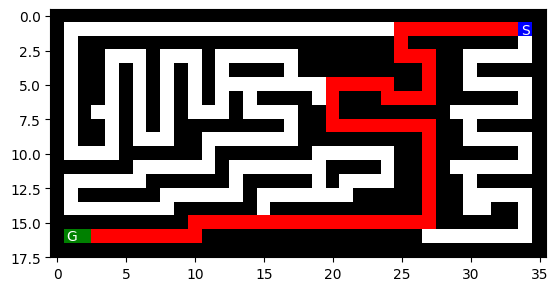

medium+1G — DFS path


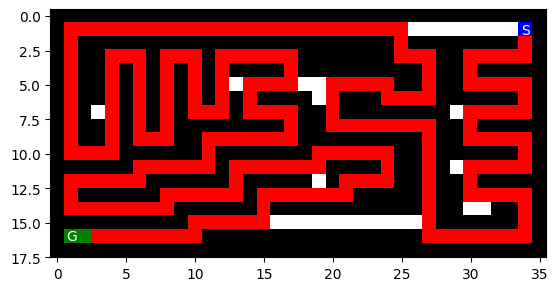

medium+1G — IDS path


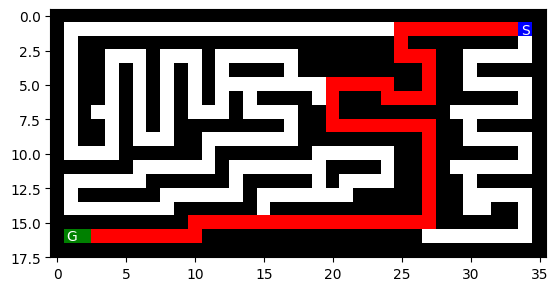

medium+2G — BFS path


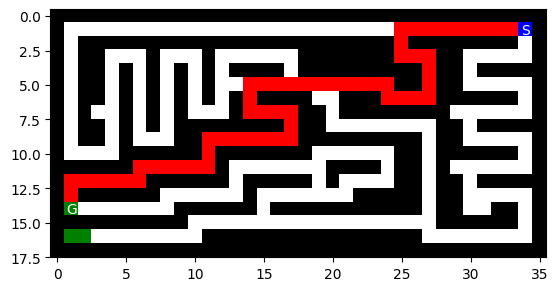

medium+2G — DFS path


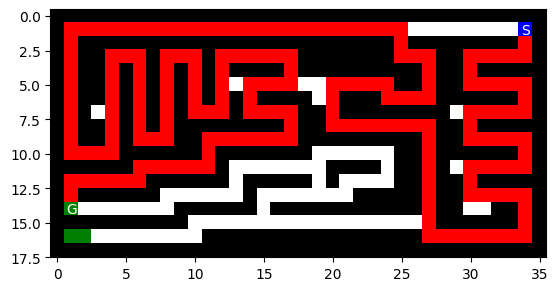

medium+2G — IDS path


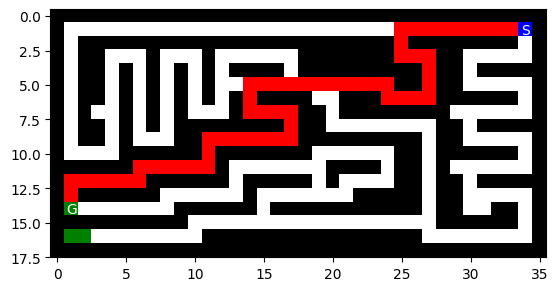

In [14]:
import os, math, itertools
import numpy as np
import pandas as pd
import maze_helper as mh
from collections import deque
from textwrap import dedent

FALLBACK_MAZES = {
    "small_maze.txt": dedent("""
        XXXXXXXXXXXXXXXXXXXXXX
        X XX        X X      X
        X    XXXXXX X XXXXXX X
        XXXXXX     S  X      X
        X    X XXXXXX XX XXXXX
        X XXXX X         X   X
        X        XXX XXX   X X
        XXXXXXXXXX    XXXXXX X
        XG         XX        X
        XXXXXXXXXXXXXXXXXXXXXX
    """).strip("\n")
}

def try_load_maze(file_name: str):
    candidates = [
        file_name,
        os.path.join("mazes", file_name),
        os.path.join(".", "mazes", file_name),
        os.path.join("/mnt/data", file_name),
    ]
    for p in candidates:
        if os.path.exists(p):
            with open(p, "r") as f:
                return mh.parse_maze(f.read()), f"loaded from {p}"
    # fallback to small if medium is missing, just so the cell runs
    if file_name == "medium_maze.txt" and "small_maze.txt" in FALLBACK_MAZES:
        return mh.parse_maze(FALLBACK_MAZES["small_maze.txt"]), "fallback small_maze (medium not found)"
    return None, f"not found in {candidates}"

DIRECTIONS = {
    "north": (-1, 0),
    "east":  (0,  1),
    "south": (1,  0),
    "west":  (0, -1),
}
ACTION_ORDER = ["north", "east", "south", "west"]

def in_bounds(M, p):
    x, y = p
    H, W = M.shape
    return 0 <= x < H and 0 <= y < W

def passable(M, p):
    return mh.look(M, p) != "X"

def neighbors(M, p):
    for a in ACTION_ORDER:
        d = DIRECTIONS[a]
        nxt = (p[0] + d[0], p[1] + d[1])
        if in_bounds(M, nxt) and passable(M, nxt):
            yield a, nxt

def manhattan(a, b):
    return abs(a[0]-b[0]) + abs(a[1]-b[1])

def all_goals(M):
    H, W = M.shape
    G = set()
    for r in range(H):
        for c in range(W):
            if M[r, c] == "G":
                G.add((r, c))
    if not G:
        G.add(tuple(mh.find_pos(M, what="G")))
    return G

def rebuild_path(parent, start, goal):
    out = []
    cur = goal
    while cur is not None:
        out.append(cur)
        cur = parent.get(cur, None)
    out.reverse()
    if out and out[0] != start:
        out.insert(0, start)
    return out

def empty_cells(M):
    H, W = M.shape
    cells = []
    for r in range(H):
        for c in range(W):
            ch = M[r, c]
            if ch == " ":
                cells.append((r, c))
    return cells

def add_extra_goals(M, how_many=1, strategy="far_from_start"):
    """
    Place 1 or 2 additional 'G' on empty cells.
    Strategy: pick cells far from S (by Manhattan), to make it interesting.
    Returns a NEW maze array with additional Gs.
    """
    S = tuple(mh.find_pos(M, what="S"))
    candidates = empty_cells(M)
    if not candidates:
        return M.copy()

    if strategy == "far_from_start":
        candidates = sorted(candidates, key=lambda p: manhattan(p, S), reverse=True)

    M2 = M.copy()
    placed = 0
    for p in candidates:
        if placed >= how_many:
            break
        M2[p[0], p[1]] = "G"
        placed += 1
    return M2

def bfs_multi_goal(M, start, goals):
    q = deque([start])
    reached = {start}
    parent  = {start: None}
    depth   = {start: 0}

    while q:
        cur = q.popleft()
        if cur in goals:
            return rebuild_path(parent, start, cur)

        for _, nxt in neighbors(M, cur):
            if nxt not in reached:
                reached.add(nxt)
                parent[nxt] = cur
                depth[nxt] = depth[cur] + 1
                q.append(nxt)
    return None

def dfs_multi_goal(M, start, goals):
    """
    Proper memory-lean DFS: no global visited; only 'on_path' cycle check.
    Returns a path if it reaches ANY goal (not necessarily optimal).
    """
    H, W = M.shape
    on_path = np.zeros((H, W), dtype=bool)

    stack = [(start, 0, 0)]   # ((x,y), depth, next_dir_index)
    parent = {start: None}
    on_path[start[0], start[1]] = True
    dir_list = [DIRECTIONS[a] for a in ACTION_ORDER]

    while stack:
        (pos, depth_here, d_idx) = stack[-1]
        if pos in goals:
            return rebuild_path(parent, start, pos)

        # explore children up to completion
        moved = False
        while d_idx < len(dir_list):
            dx, dy = dir_list[d_idx]
            d_idx += 1
            stack[-1] = (pos, depth_here, d_idx)
            nxt = (pos[0] + dx, pos[1] + dy)

            if not in_bounds(M, nxt) or not passable(M, nxt):
                continue
            if on_path[nxt[0], nxt[1]]:
                continue  # cycle on the current path

            parent[nxt] = pos
            stack.append((nxt, depth_here + 1, 0))
            on_path[nxt[0], nxt[1]] = True
            moved = True
            break

        if not moved:
            # backtrack
            stack.pop()
            on_path[pos[0], pos[1]] = False

    return None

def dls_step(M, start, goals, limit):
    """One depth-limited DFS step (no global visited)."""
    H, W = M.shape
    on_path = np.zeros((H, W), dtype=bool)
    stack = [(start, 0, 0)]           # ((x,y), depth, next_dir_index)
    parent = {start: None}
    on_path[start[0], start[1]] = True
    dir_list = [DIRECTIONS[a] for a in ACTION_ORDER]

    while stack:
        (pos, depth_here, d_idx) = stack[-1]
        if pos in goals:
            return rebuild_path(parent, start, pos)

        if depth_here >= limit:
            stack.pop()
            on_path[pos[0], pos[1]] = False
            continue

        moved = False
        while d_idx < len(dir_list):
            dx, dy = dir_list[d_idx]
            d_idx += 1
            stack[-1] = (pos, depth_here, d_idx)
            nxt = (pos[0] + dx, pos[1] + dy)

            if not in_bounds(M, nxt) or not passable(M, nxt):
                continue
            if on_path[nxt[0], nxt[1]]:
                continue

            parent[nxt] = pos
            stack.append((nxt, depth_here + 1, 0))
            on_path[nxt[0], nxt[1]] = True
            moved = True
            break

        if not moved:
            stack.pop()
            on_path[pos[0], pos[1]] = False

    return None

def ids_multi_goal(M, start, goals, max_limit=500):
    """
    Classic IDS: depth limit = 0,1,2,... until a goal path is found or max_limit reached.
    With unit-cost steps, IDS finds an OPTIMAL-depth solution (like BFS) in trees.
    In graphs with duplicates (and only path-cycle checking), it still finds the
    shallowest goal **by depth** because limits increase one-by-one.
    """
    for limit in range(max_limit + 1):
        path = dls_step(M, start, goals, limit)
        if path is not None:
            return path, limit
    return None, None

def measure_path_cost(path):
    return len(path) - 1 if path else math.inf

def run_compare(multi_goal_maze, name):
    S = tuple(mh.find_pos(multi_goal_maze, what="S"))
    Gs = all_goals(multi_goal_maze)

    # BFS (ground truth for optimal cost in unit-cost domains)
    bfs_path = bfs_multi_goal(multi_goal_maze, S, Gs)
    bfs_cost = measure_path_cost(bfs_path)

    dfs_path = dfs_multi_goal(multi_goal_maze, S, Gs)
    dfs_cost = measure_path_cost(dfs_path)

    ids_path, _ = ids_multi_goal(multi_goal_maze, S, Gs, max_limit=2000)
    ids_cost = measure_path_cost(ids_path)

    rows = []
    def add_row(algo, cost):
        optimal = (cost == bfs_cost)
        rows.append({
            "maze": name,
            "algorithm": algo,
            "path cost": cost if math.isfinite(cost) else "N/A*",
            "optimal?": "yes" if optimal else "no"
        })

    add_row("BFS", bfs_cost)
    add_row("DFS", dfs_cost)
    add_row("IDS", ids_cost)

    return pd.DataFrame(rows, columns=["maze", "algorithm", "path cost", "optimal?"]), (bfs_path, dfs_path, ids_path)

base_maze, src = try_load_maze("medium_maze.txt")
print(f"Loaded base for multi-goal tests: {src}")

# Variant A: add 1 extra goal
maze_plus1 = add_extra_goals(base_maze, how_many=1, strategy="far_from_start")
# Variant B: add 2 extra goals
maze_plus2 = add_extra_goals(base_maze, how_many=2, strategy="far_from_start")

dfA, pathsA = run_compare(maze_plus1, "medium+1G")
dfB, pathsB = run_compare(maze_plus2, "medium+2G")

results = pd.concat([dfA, dfB], ignore_index=True)
print("\n=== Multi-goal Results (BFS as optimal baseline) ===")
print(results.to_string(index=False))

# Optional: visualize one example per variant (final path only)
def show_path(M, path, title):
    if path is None:
        print(f"{title}: no path")
        mh.show_maze(M)
        return
    S = tuple(mh.find_pos(M, what="S"))
    Gs = all_goals(M)
    M2 = M.copy()
    for p in path:
        if p != S and p not in Gs:
            M2[p[0], p[1]] = "P"
    # restore labels
    M2[S[0], S[1]] = "S"
    for g in Gs:
        M2[g[0], g[1]] = "G"
    print(title)
    mh.show_maze(M2)

bfsA, dfsA, idsA = pathsA
bfsB, dfsB, idsB = pathsB

show_path(maze_plus1, bfsA, "medium+1G — BFS path")
show_path(maze_plus1, dfsA, "medium+1G — DFS path")
show_path(maze_plus1, idsA, "medium+1G — IDS path")

show_path(maze_plus2, bfsB, "medium+2G — BFS path")
show_path(maze_plus2, dfsB, "medium+2G — DFS path")
show_path(maze_plus2, idsB, "medium+2G — IDS path")


## More Advanced Problems to Think About (not for credit)

If the assignment was to easy for yuo then you can think about the following problems. These problems are challenging and not part of this assignment.

### Intersection as States
Instead of defining each square as a state, use only intersections as states. Now the storage requirement is reduced, but the path length between two intersections can be different. If we use total path length measured as the number of squares as path cost, how can we make sure that BFS and iterative deepening search is optimal? Change the code to do so.

In [ ]:
# Your code/answer goes here

### Weighted A* search
Modify your A* search to add weights (see text book) and explore how different weights influence the result.

In [ ]:
# Your code/answer goes here

### Unknown Maze
What happens if the agent does not know the layout of the maze in advance? This means that the agent faces an unknown environment, where it does not know the transition function. How does the environment look then (PEAS description)? How would you implement a rational agent to solve the maze? What if the agent still has a GPS device to tell the distance to the goal?

In [ ]:
# Your code/answer goes here